# Fraud Detection Prediction Model

### Business Problem
Bluewhale Bank faces problems of rising fraud losses, high false-positive rates and increasing customer dissatisfaction due to incorrectly blocked legitimate transactions. To address this, management has approved the deployment of Machine Learning model to identify fraudulent transactions in near real time to prevent financial loss while preserving customer experience. 

### Prediction Target
The target variable is Fraud_Label where: 
1 = Fraud
0 = non_fraud

### Dataset Link

https://www.kaggle.com/datasets/samayashar/fraud-detection-transactions-dataset


### Notebook Overview
This notebook follows the machine learning steps:
1. Import necessary libraries
2. Load and inspect the dataset
3. Clean and prepare the dataset
4. Exploratory data analysis (EDA)
5. Feature engineering
6. Training and Testing set split
7. Preprocessing and modelling pipelines
8. Model Selection using 5-fold cross-validation
9. Tune the best model
10. Evaluate the final model
11. Comparison of untuned and tuned selected models
12. Threshold selection
13. Final test set evaluation
14. Model interpretation and feature importance with SHAP


In [1]:
# IMPORTS THE NECESSARY LIBRARIES

# Standard Library
import math
import warnings

# Data Manipulation
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Statistical Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Scikit-learn — Data Splitting & Validation
from sklearn.base import clone
from sklearn.exceptions import NotFittedError
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)

# Scikit-learn — Preprocessing & Pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

# Scikit-learn — Models
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Scikit-learn — Evaluation Metrics
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    auc,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Third-party Models
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings('ignore')


### Data Understanding and Quality Assesment 

In [2]:
# Load the dataset
filepath = 'fraud_detection_dataset.csv'
df = pd.read_csv(filepath)

In [3]:
df.head(5)

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,14/08/2023 19:30,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,07/06/2023 04:01,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,20/06/2023 15:25,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,07/12/2023 00:31,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,11/11/2023 23:44,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [4]:
# Check rows and columns
df.shape

(50000, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [7]:
# Unique Locations
df['Location'].unique()

<StringArray>
['Sydney', 'New York', 'Mumbai', 'Tokyo', 'London']
Length: 5, dtype: str

In [8]:
# Summary Table for Data Types, Missing Values, and Unique Values
summary = pd.DataFrame({
    "Data_Type": df.dtypes,
    "Non_Null_Count": df.notnull().sum(),
    "Missing_Count": df.isnull().sum(),
    "Missing_%": round(df.isnull().mean() * 100, 2),
    "Unique_Values": df.nunique()
})

summary

,Data_Type,Non_Null_Count,Missing_Count,Missing_%,Unique_Values
Transaction_ID,str,50000,0,0.0,50000
User_ID,str,50000,0,0.0,8963
Transaction_Amount,float64,50000,0,0.0,21763
Transaction_Type,str,50000,0,0.0,4
Timestamp,str,50000,0,0.0,47724
Account_Balance,float64,50000,0,0.0,49867
Device_Type,str,50000,0,0.0,3
Location,str,50000,0,0.0,5
Merchant_Category,str,50000,0,0.0,5
IP_Address_Flag,int64,50000,0,0.0,2


In [9]:
# Target binary check
df['Fraud_Label'].unique()

array([0, 1])

In [10]:
# Identify Feature Categories
target = "Fraud_Label"

# Explicit identifier columns
identifier_cols = ['Transaction_ID', 'User_ID']

# redefine features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove(target)

binary_features = [col for col in numerical_features if df[col].nunique() == 2]
continuous_features = [col for col in numerical_features if df[col].nunique() > 2]

categorical_features = df.select_dtypes(include=['object', 'string']).columns.tolist()

# Remove identifiers from categorical list
categorical_features = [col for col in categorical_features if col not in identifier_cols]

print("Continuous:", continuous_features)
print("Binary:", binary_features)
print("Categorical:", categorical_features)
print("Identifiers:", identifier_cols)

Continuous: ['Transaction_Amount', 'Account_Balance', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score']
Binary: ['IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Is_Weekend']
Categorical: ['Transaction_Type', 'Timestamp', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']
Identifiers: ['Transaction_ID', 'User_ID']


In [11]:
# Feature Binary Check
for col in ['IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Is_Weekend']:
    print(col, df[col].unique())

IP_Address_Flag [0 1]
Previous_Fraudulent_Activity [0 1]
Is_Weekend [0 1]


In [12]:
# Target binary check
df['Fraud_Label'].unique()

array([0, 1])

In [13]:
# Continuous features summary
df[continuous_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Amount,50000.0,99.411012,98.687292,0.0000,28.6775,69.66000,138.852500,1174.14
Account_Balance,50000.0,50294.065981,28760.458557,500.4800,25355.9950,50384.43000,75115.135000,99998.31
Daily_Transaction_Count,50000.0,7.485240,4.039637,1.0000,4.0000,7.00000,11.000000,14.00
Avg_Transaction_Amount_7d,50000.0,255.271924,141.382279,10.0000,132.0875,256.08500,378.032500,500.00
Failed_Transaction_Count_7d,50000.0,2.003540,1.414273,0.0000,1.0000,2.00000,3.000000,4.00
Card_Age,50000.0,119.999940,68.985817,1.0000,60.0000,120.00000,180.000000,239.00
Transaction_Distance,50000.0,2499.164155,1442.013834,0.2500,1256.4975,2490.78500,3746.395000,4999.93
Risk_Score,50000.0,0.501556,0.287774,0.0001,0.2540,0.50225,0.749525,1.00


In [14]:
# Validate Identifiers
for col in identifier_cols:
    unique_count = df[col].nunique()
    total_count = len(df)
    print(f"{col}: {unique_count} unique values out of {total_count} rows")

Transaction_ID: 50000 unique values out of 50000 rows
User_ID: 8963 unique values out of 50000 rows


In [15]:
# User_ID distribution
df['User_ID'].value_counts().describe()

count    8963.000000
mean        5.578489
std         2.331861
min         1.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        16.000000
Name: count, dtype: float64

In [16]:
# Average fraud rate per user
df.groupby('User_ID')['Fraud_Label'].mean().describe()

count    8963.000000
mean        0.321059
std         0.221378
min         0.000000
25%         0.166667
50%         0.333333
75%         0.500000
max         1.000000
Name: Fraud_Label, dtype: float64

In [17]:
# Logical consistency check 
(df['Avg_Transaction_Amount_7d'] < 0).sum()

np.int64(0)

In [18]:
# Logical consistency check
(df['Daily_Transaction_Count'] == 0).sum()

np.int64(0)

In [19]:
# Monetary Logical consistency check
(df['Transaction_Amount'] > df['Account_Balance']).mean()

np.float64(2e-05)

In [20]:
# Transaction Amount Distribution by Location
df.groupby('Location')['Transaction_Amount'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)

,mean,median,std
Location,,,
New York,100.887441,69.770,101.124142
Sydney,100.318586,71.785,98.775171
London,99.154441,70.140,96.532460
Mumbai,98.564401,68.375,97.914677
Tokyo,98.172216,67.895,99.027727


In [21]:
# Fraud Rate by Location
df.groupby('Location')['Fraud_Label'].mean().sort_values(ascending=False)

Location
New York    0.324861
Tokyo       0.324745
Sydney      0.321393
London      0.319859
Mumbai      0.315789
Name: Fraud_Label, dtype: float64

In [22]:
# Fraud Rate by Device Type
df.groupby('Device_Type')['Fraud_Label'].mean().sort_values(ascending=False)

Device_Type
Tablet    0.325645
Laptop    0.319522
Mobile    0.318810
Name: Fraud_Label, dtype: float64

In [23]:
# Risk Score Distribution
df['Risk_Score'].describe()

count    50000.000000
mean         0.501556
std          0.287774
min          0.000100
25%          0.254000
50%          0.502250
75%          0.749525
max          1.000000
Name: Risk_Score, dtype: float64

In [24]:
df['Risk_Score'].min(), df['Risk_Score'].max()

(np.float64(0.0001), np.float64(1.0))

In [ ]:
# Convert Timestamp column to datetime format (day-first to match dataset format)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], dayfirst=True)

# Display earliest and latest transaction timestamps to understand temporal coverage
print("Min timestamp:", df['Timestamp'].min())
print("Max timestamp:", df['Timestamp'].max())

# Calculate total time span of the dataset in days
print("Date range (days):", (df['Timestamp'].max() - df['Timestamp'].min()).days)

Min timestamp: 2023-01-01 00:01:00
Max timestamp: 2023-12-31 23:50:00
Date range (days): 364


In [26]:
# Fraud rate across months
df['Month'] = df['Timestamp'].dt.month

df.groupby('Month')['Fraud_Label'].mean()

Month
1     0.330946
2     0.319242
3     0.319324
4     0.319045
5     0.315954
6     0.323798
7     0.321386
8     0.327099
9     0.311965
10    0.322526
11    0.318482
12    0.325484
Name: Fraud_Label, dtype: float64

## Dataset Overview
The dataset contains 50,000 observations, each representing an individual financial transaction. The target variable, Fraud_Label, is binary (0 = legitimate, 1 = fraudulent).

There are 8,963 unique users (User_ID). Each user conducts an average of 5.6 transactions (median = 5, maximum = 16), confirming that the dataset is transaction-level with repeated user observations rather than user-level aggregates.

#### Feature Structural Roles

Features were grouped according to their conceptual role within the transaction lifecycle.

* Continuous Monetary Features: These represent financial magnitude and liquidity context. Transaction amounts are positively skewed but internally consistent. Only 0.002% of transactions exceed the reported account balance, indicating strong logical coherence.

* Behavioural Aggregates: These variables describe recent behavioural activity and customer history. Features referencing “7d” are rolling window aggregates.

Logical validation confirmed:

No negative rolling averages.
No zero daily transaction counts in a transaction-level dataset.

* Risk Indicator

Risk_Score

Risk_Score is bounded between 0.0001 and 1.0, with a mean of approximately 0.50 and a near-uniform distribution across its range. This structure suggests it may represent a pre-engineered probabilistic risk measure rather than a raw transactional input.

Its bounded nature and central distribution raise the possibility that it may strongly correlate with the target and dominate predictive performance. Controlled modelling experiments will therefore be conducted both with and without this variable.

* Binary Indicators: All binary features are correctly encoded as 0/1 indicators with no invalid values detected.

* Categorical Contextual Features

These describe transaction context. Fraud rates across Location vary only between 31.6% and 32.5%, and across Device_Type between 31.9% and 32.6%, indicating minimal demographic differentiation in fraud prevalence. This suggests that fraud is neither location nor device type. 

* Identifiers: Transaction_ID is fully unique, confirming no duplicate transaction records.
User_ID repeats across observations, introducing user-level dependency.


#### Geographic and Monetary Consistency 
Transaction amounts are statistically similar across all geographic locations.

Mean transaction amounts range from approximately 98 to 101.

Standard deviations are comparable across cities.

This confirms that transaction values do not represent location-specific currencies. Currency normalisation was therefore not applied, as no evidence supports multiple monetary scales.

#### User-Level Dependency Structure

Per-user fraud rate analysis reveals substantial variation:

Some users exhibit 0% fraud.

Some users exhibit 100% fraud.

Median user-level fraud rate ≈ 33%.

This indicates strong clustering of fraud behaviour at the user level. Since users appear multiple times, observations are not independent. A purely random train-test split may allow transactions from the same user to appear in both training and test sets, potentially inflating performance. 

#### Data Quality Assessment

The dataset demonstrates strong structural integrity:

No missing values detected.

No duplicate transaction records.

No negative monetary values.

No logically inconsistent daily counts.

Minimal inconsistency between transaction amount and account balance.

These checks suggest a clean and internally coherent dataset.

## Data Cleaning
* Timestamp Conversion and Coverage

The Timestamp variable was converted to datetime format using explicit day-first parsing to ensure correct interpretation of the original format:

The dataset spans the full 2023 calendar year:

This confirms that transactions are distributed across an entire year rather than concentrated within a short synthetic window. The presence of full-year coverage supports the plausibility of time-window aggregates such as 7-day behavioural features.

Temporal Distribution of Fraud

To assess temporal stability, fraud prevalence was examined on a monthly basis:

Fraud rates vary between approximately 31.2% and 33.1%, representing a range of less than two percentage points across the year.

This indicates:

No strong seasonal effect.

No clear upward or downward drift.

Stable fraud prevalence over time.


Derived features such as hour of day and day of week will be extracted to capture temporal patterns.

# Exploratory Data Analysis

### Univariate Analysis
* Feature-Level analysis to understand distribution, skewness, spread

In [ ]:
# Univariate analysis for continuous features

#  Monetary features: represent financial magnitude of transactions and account status
monetary_features = [
    'Transaction_Amount',
    'Account_Balance'
]

# Behavioural features: capture user activity patterns and recent transaction behaviour
behavioural_features = [
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Failed_Transaction_Count_7d',
    'Transaction_Distance',
    'Card_Age'
]
# Risk-based feature: externally derived or model-based risk indicator
risk_feature = ['Risk_Score']

In [ ]:
# summary statistics for continuous feature groups
def univariate_summary(features, group_name):
    # Compute standard descriptive statistics (mean, std, min, max, quartiles)
    summary = df[features].describe().T
    # Add skewness to assess distribution shape (useful for detecting skewed variables)
    summary['skewness'] = df[features].skew()
    print(f"\n===== {group_name} =====")
    display(summary)
# Apply function to each feature group
univariate_summary(monetary_features, "Monetary Features")
univariate_summary(behavioural_features, "Behavioural Features")
univariate_summary(risk_feature, "Risk Score")


===== Monetary Features =====


,count,mean,std,min,25%,50%,75%,max,skewness
Transaction_Amount,50000.0,99.411012,98.687292,0.00,28.6775,69.66,138.8525,1174.14,1.996036
Account_Balance,50000.0,50294.065981,28760.458557,500.48,25355.9950,50384.43,75115.1350,99998.31,-0.003025



===== Behavioural Features =====


,count,mean,std,min,25%,50%,75%,max,skewness
Daily_Transaction_Count,50000.0,7.485240,4.039637,1.00,4.0000,7.000,11.0000,14.00,0.003684
Avg_Transaction_Amount_7d,50000.0,255.271924,141.382279,10.00,132.0875,256.085,378.0325,500.00,-0.000909
Failed_Transaction_Count_7d,50000.0,2.003540,1.414273,0.00,1.0000,2.000,3.0000,4.00,-0.008803
Transaction_Distance,50000.0,2499.164155,1442.013834,0.25,1256.4975,2490.785,3746.3950,4999.93,0.006449
Card_Age,50000.0,119.999940,68.985817,1.00,60.0000,120.000,180.0000,239.00,0.000512



===== Risk Score =====


,count,mean,std,min,25%,50%,75%,max,skewness
Risk_Score,50000.0,0.501556,0.287774,0.0001,0.254,0.50225,0.749525,1.0,-0.001319


##### Histograms for continous feature groups

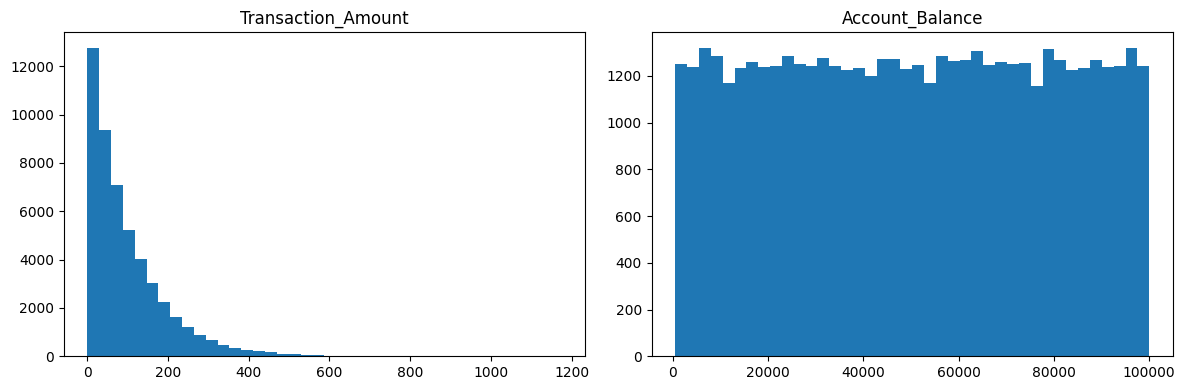

In [29]:
# Histograms for monetary features

fig, axes = plt.subplots(1, len(monetary_features), figsize=(12,4))

for i, col in enumerate(monetary_features):
    axes[i].hist(df[col], bins=40)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [30]:
df['Account_Balance'].skew()

np.float64(-0.0030254835855370804)

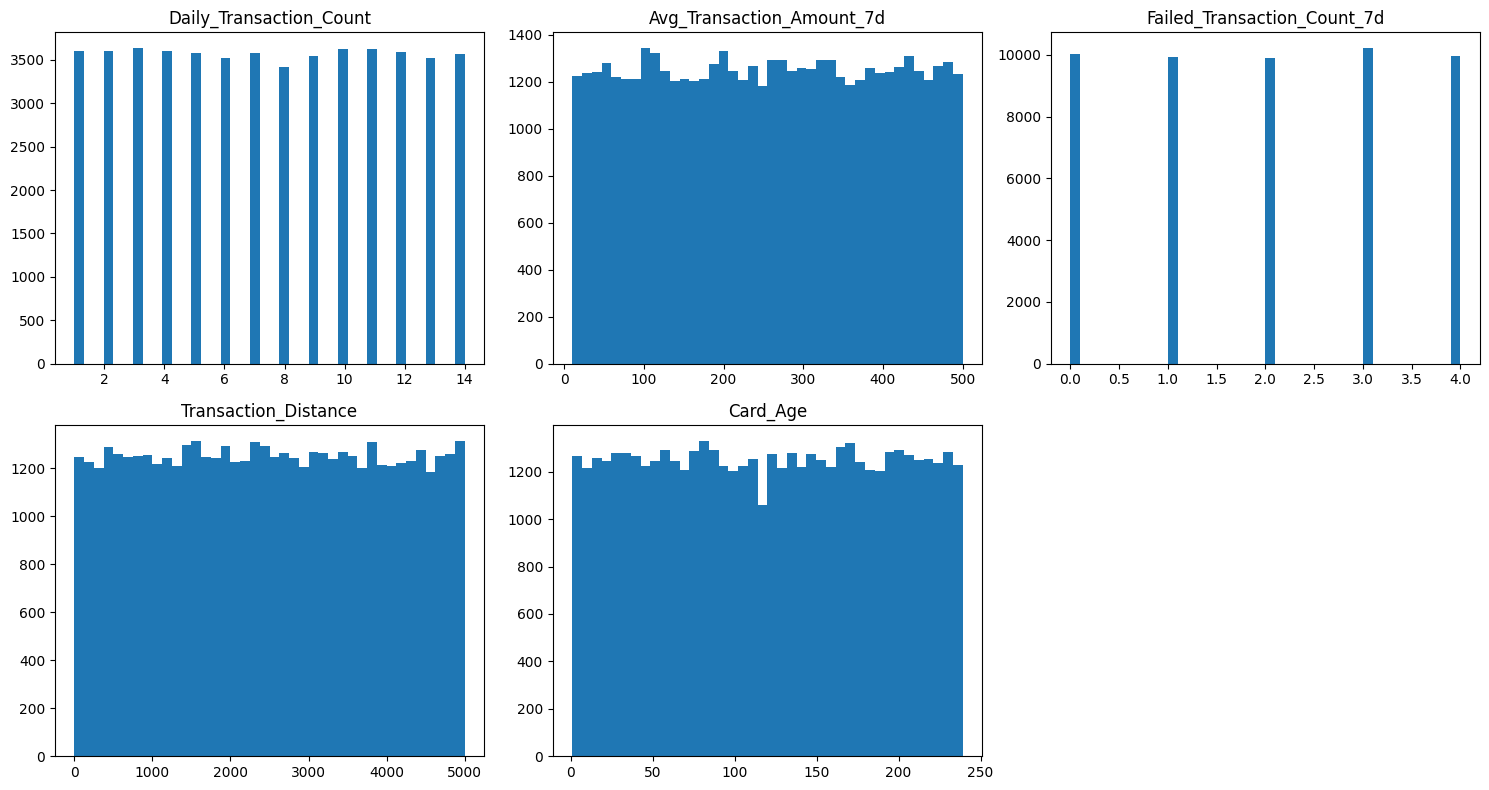

In [31]:
# Histogram for behavioural features  
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(behavioural_features):
    axes[i].hist(df[col], bins=40)
    axes[i].set_title(col)

# Remove unused subplot if any
for j in range(len(behavioural_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

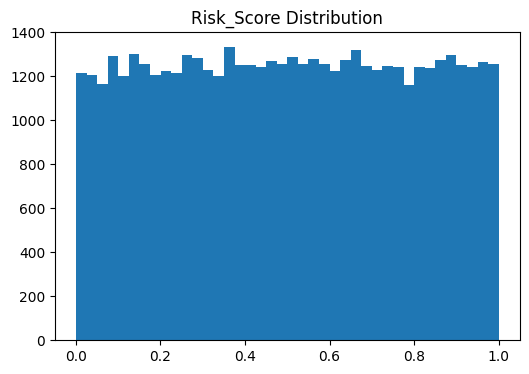

In [32]:
# Histogram for Risk_Score Distribution
plt.figure(figsize=(6,4))
plt.hist(df['Risk_Score'], bins=40)
plt.title("Risk_Score Distribution")
plt.show()

##### Visualization of outliers for continuous feature groups

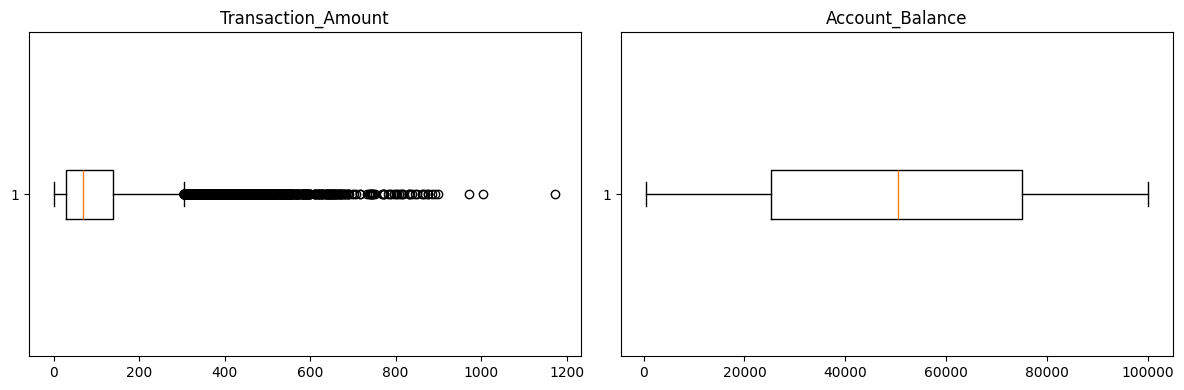

In [33]:
# Boxplots for monetary features
fig, axes = plt.subplots(1, len(monetary_features), figsize=(12,4))

for i, col in enumerate(monetary_features):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

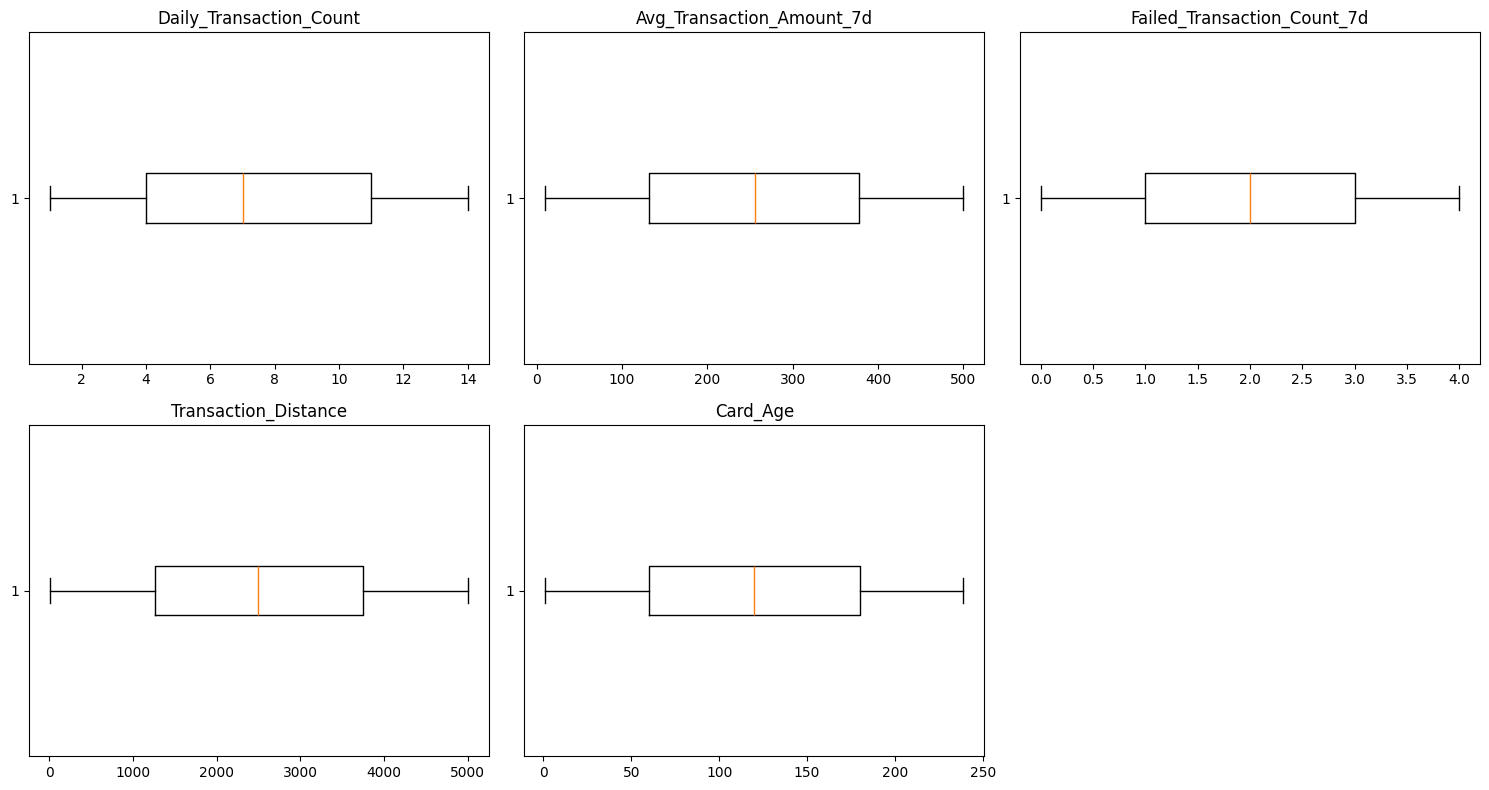

In [34]:
# Boxplots for behavioural features
fig, axes = plt.subplots(2, 3, figsize=(15,8))
axes = axes.flatten()

for i, col in enumerate(behavioural_features):
    axes[i].boxplot(df[col], vert=False)
    axes[i].set_title(col)

for j in range(len(behavioural_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### Tables for binary feature groups

In [35]:
# Define Binary Features
binary_features = [
    'IP_Address_Flag',
    'Previous_Fraudulent_Activity',
    'Is_Weekend'
]

In [36]:
# Check unique values for binary features
for col in binary_features:
    print(f"{col}: {sorted(df[col].unique())}")

IP_Address_Flag: [np.int64(0), np.int64(1)]
Previous_Fraudulent_Activity: [np.int64(0), np.int64(1)]
Is_Weekend: [np.int64(0), np.int64(1)]


In [37]:
# proportion table for binary features
binary_summary = []

for col in binary_features:
    value_counts = df[col].value_counts(normalize=True).sort_index()
    binary_summary.append({
        "Feature": col,
        "Proportion_0": round(value_counts.get(0, 0), 4),
        "Proportion_1": round(value_counts.get(1, 0), 4)
    })

binary_summary_df = pd.DataFrame(binary_summary)
binary_summary_df

,Feature,Proportion_0,Proportion_1
0,IP_Address_Flag,0.9498,0.0502
1,Previous_Fraudulent_Activity,0.9016,0.0984
2,Is_Weekend,0.7004,0.2996


##### Univariate Analysis for categorical features

In [38]:
# Define categorical features
categorical_features = [
    'Transaction_Type',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Card_Type',
    'Authentication_Method'
]

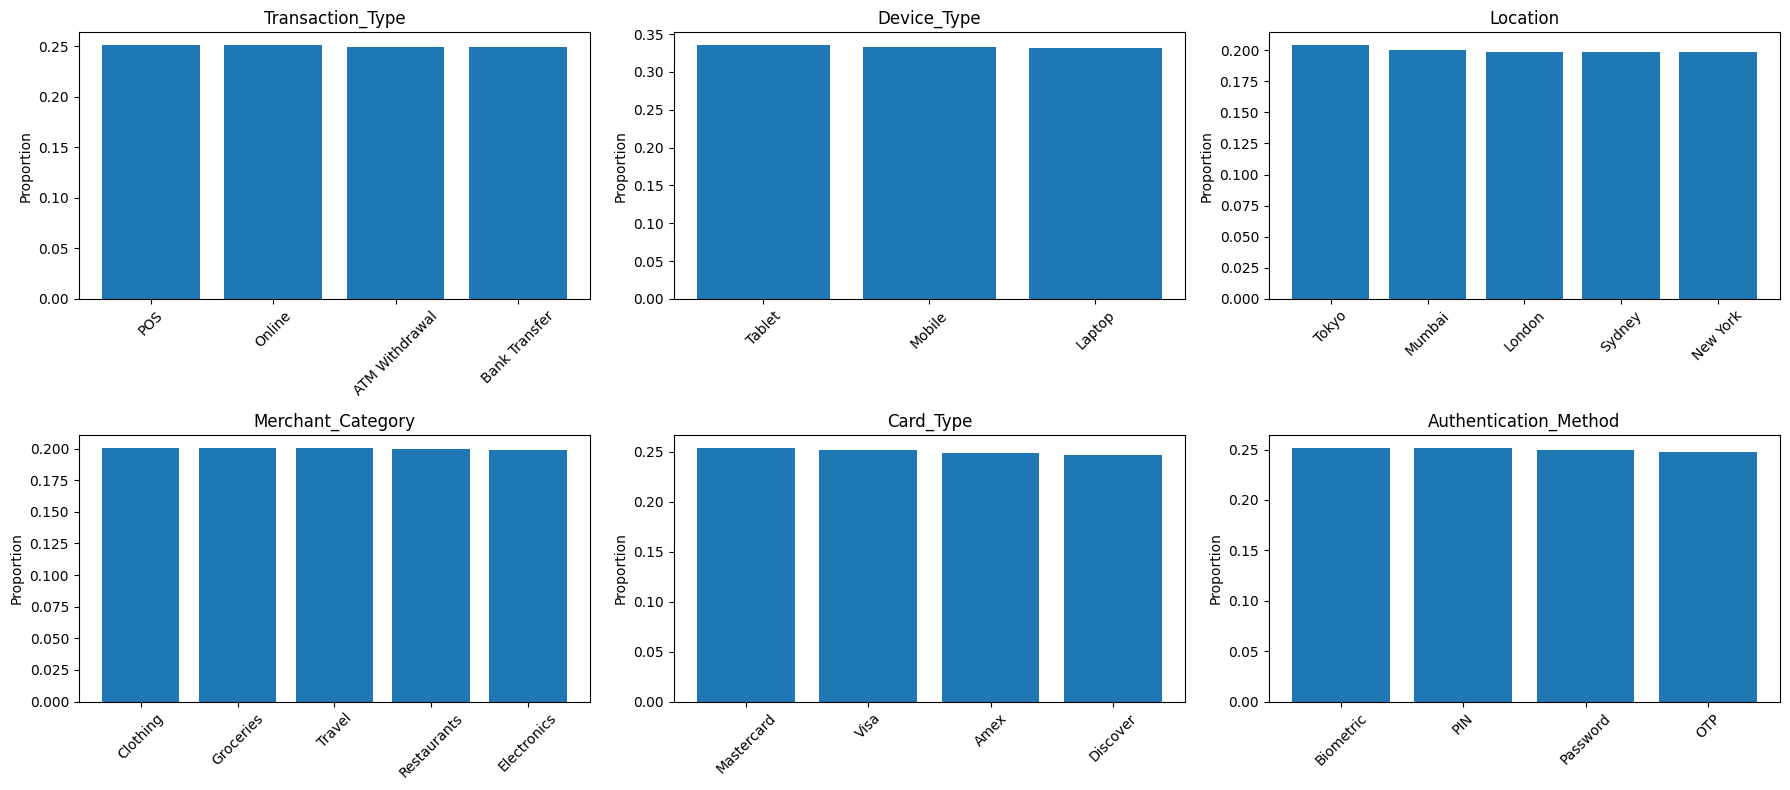

In [39]:
# subplot for categorical features
n = len(categorical_features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    proportions = df[col].value_counts(normalize=True).sort_values(ascending=False)
    
    axes[i].bar(proportions.index, proportions.values)
    axes[i].set_title(col)
    axes[i].set_ylabel("Proportion")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



### Bivariate Analysis

In [40]:
# Define continous features to compare between fraud and non-fraud
features_to_compare = [
    'Transaction_Amount',
    'Account_Balance',
    'Card_Age',
    'Failed_Transaction_Count_7d',
    'Daily_Transaction_Count',
    'Avg_Transaction_Amount_7d',
    'Transaction_Distance',
    'Risk_Score'
]

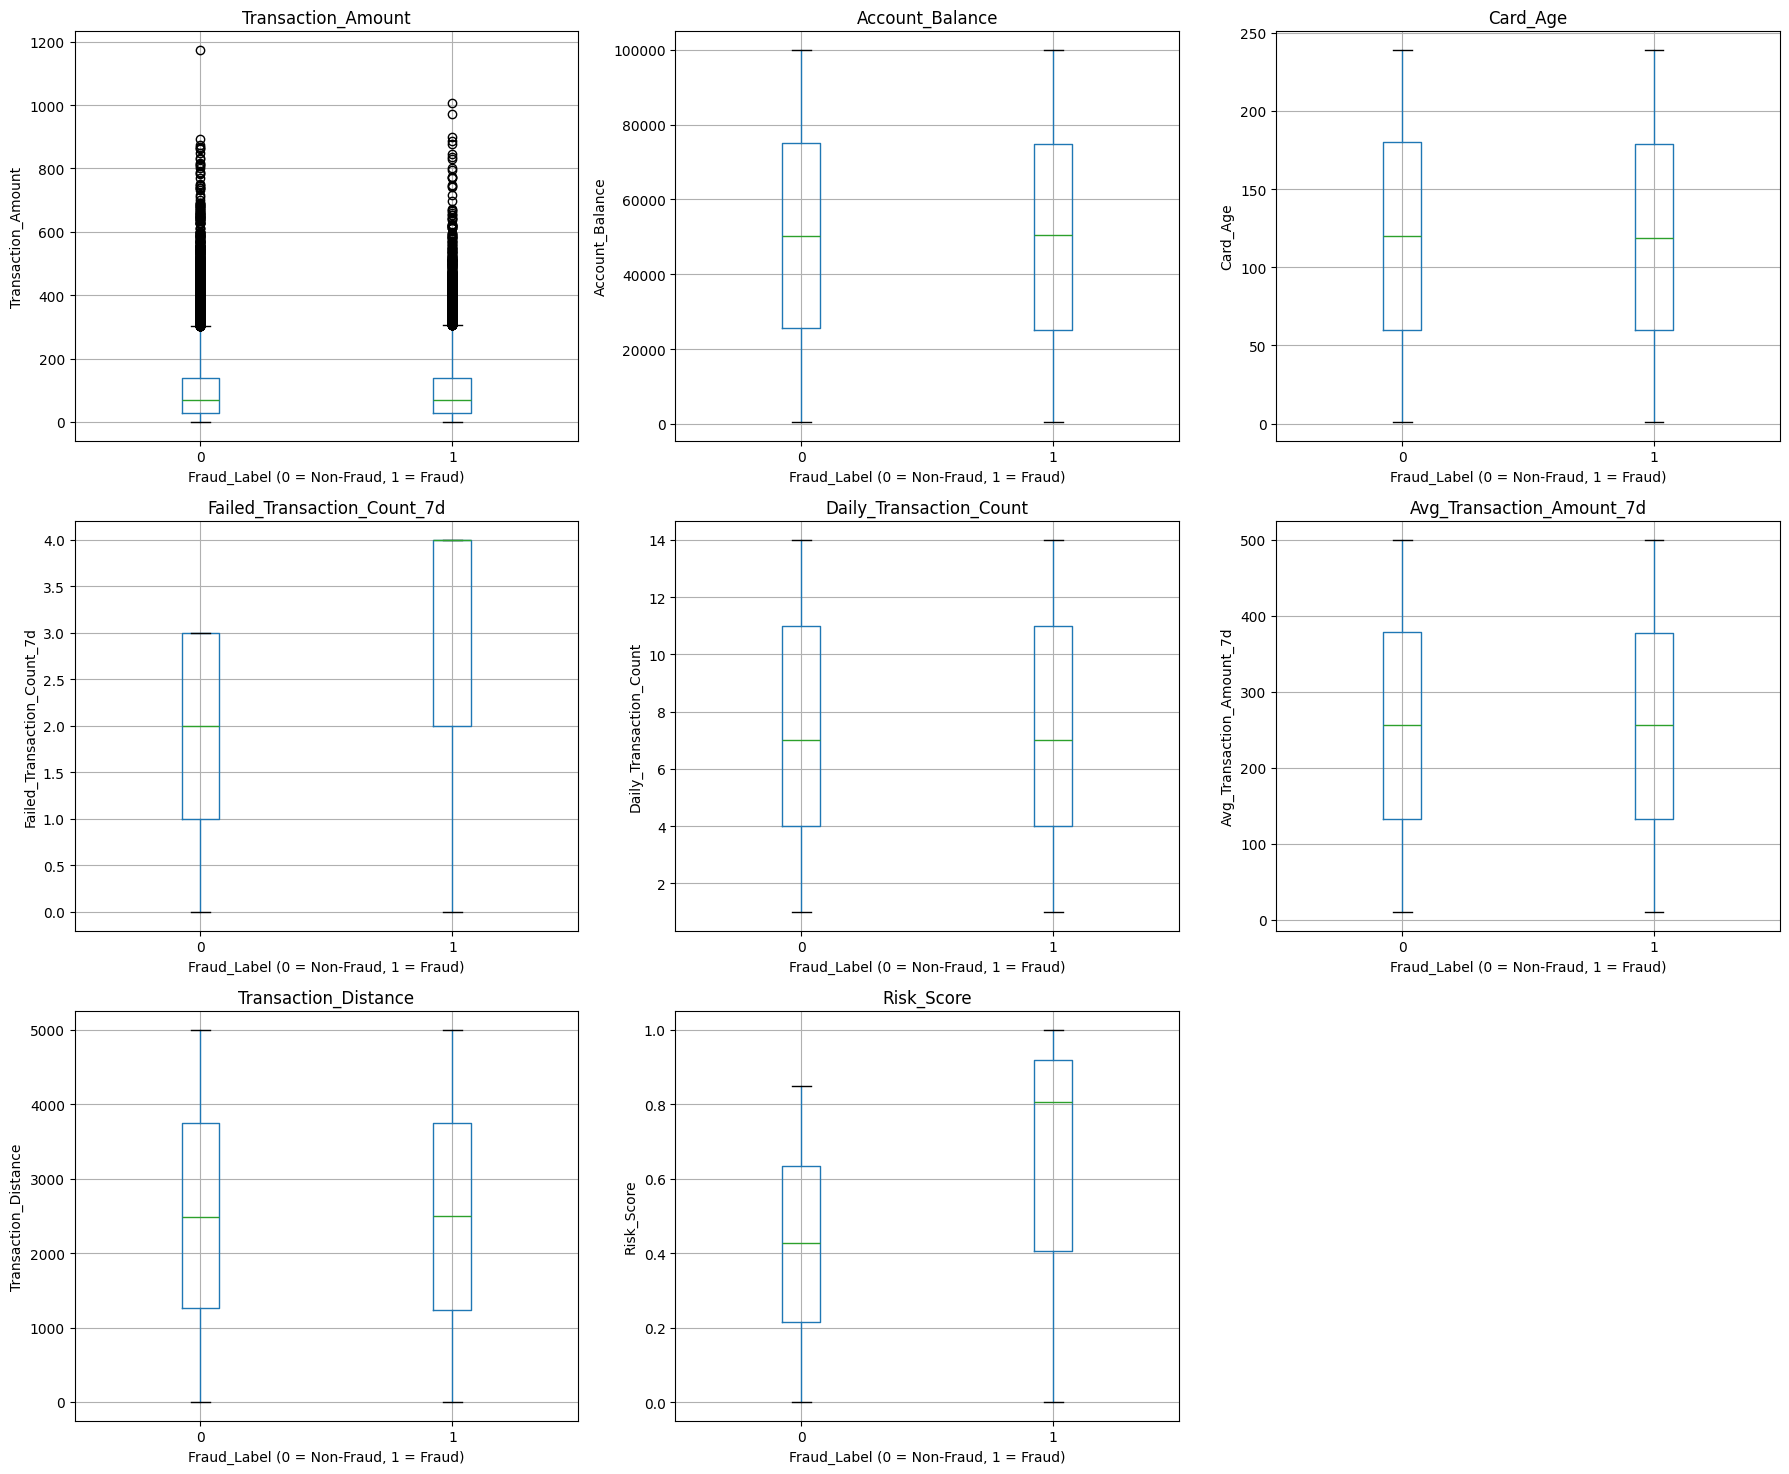

In [41]:
# Boxplot for each continous feature by Fraud_Label

cols = 3
rows = math.ceil(len(features_to_compare) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(features_to_compare):
    df.boxplot(column=col, by='Fraud_Label', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("Fraud_Label (0 = Non-Fraud, 1 = Fraud)")
    axes[i].set_ylabel(col)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()
plt.show()

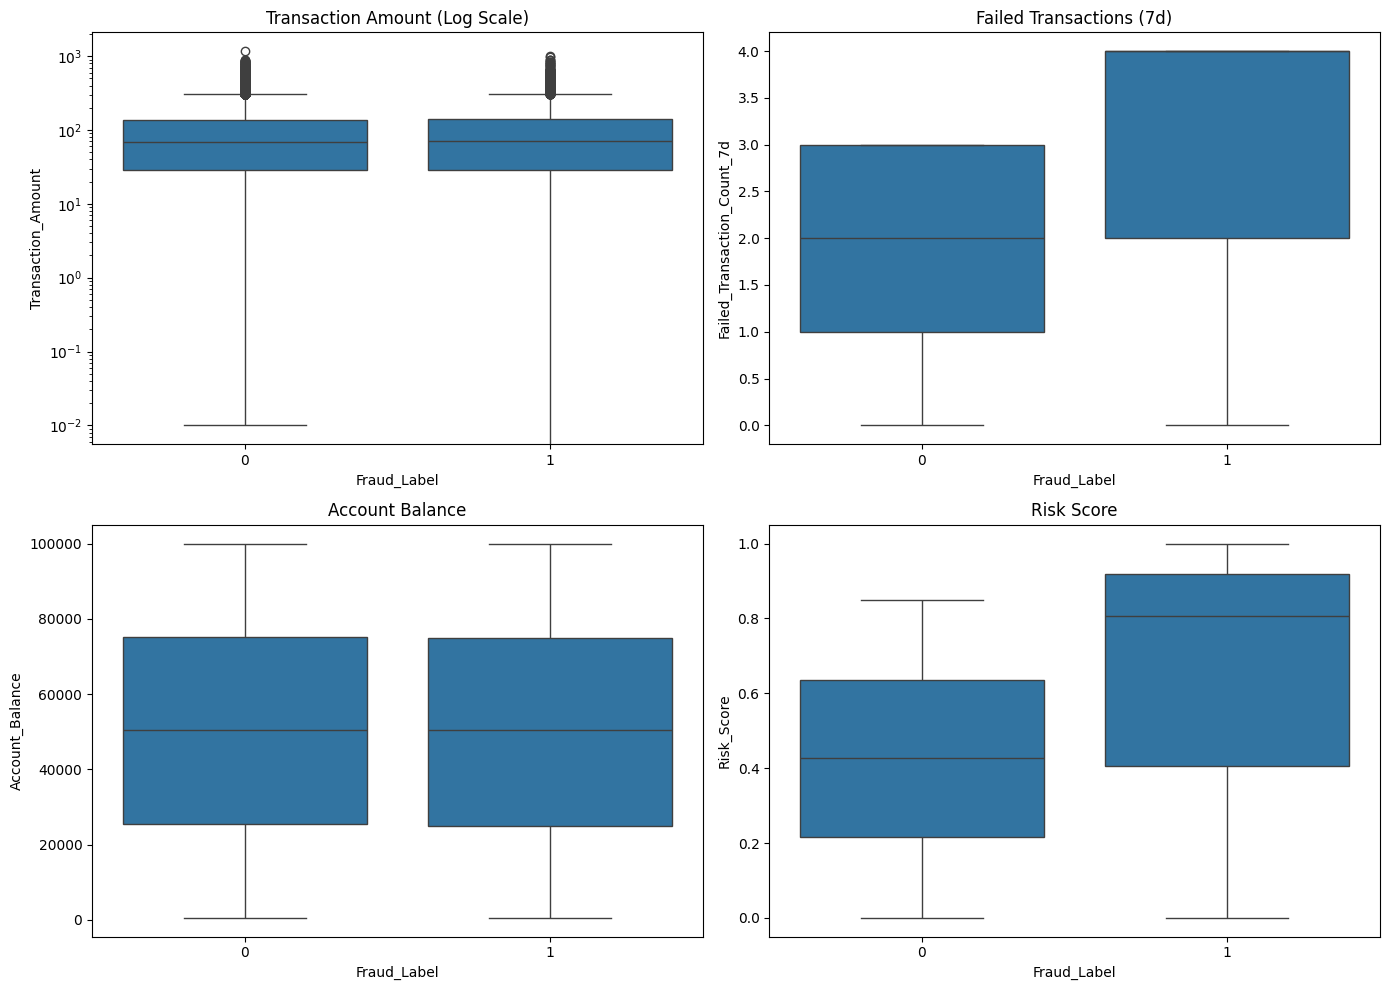

In [42]:
# box plot for each continous feature by Target (Fraud_Label)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Transaction Amount (log scale)
sns.boxplot(
    x='Fraud_Label',
    y='Transaction_Amount',
    data=df,
    ax=axes[0,0]
)
axes[0,0].set_yscale('log')
axes[0,0].set_title("Transaction Amount (Log Scale)")

# 2. Failed Transactions
sns.boxplot(
    x='Fraud_Label',
    y='Failed_Transaction_Count_7d',
    data=df,
    ax=axes[0,1]
)
axes[0,1].set_title("Failed Transactions (7d)")

# 3. Account Balance
sns.boxplot(
    x='Fraud_Label',
    y='Account_Balance',
    data=df,
    ax=axes[1,0]
)
axes[1,0].set_title("Account Balance")

# 4. Risk Score
sns.boxplot(
    x='Fraud_Label',
    y='Risk_Score',
    data=df,
    ax=axes[1,1]
)
axes[1,1].set_title("Risk Score")

plt.tight_layout()
plt.show()

Transaction magnitude and account balance exhibit substantial overlap between classes (fraud and non-fraud can not be easily distinguished), whereas behavioural indicators such as failed transaction count show upward shift for fraudulent activity while Risk score exhibits the strongest class separation, suggesting it is a primary predictive driver

In [43]:
# Define categorical features to compare between fraud and non-fraud
categorical_features = [
    'Transaction_Type',
    'Device_Type',
    'Location',
    'Merchant_Category',
    'Card_Type',
    'Authentication_Method'
]

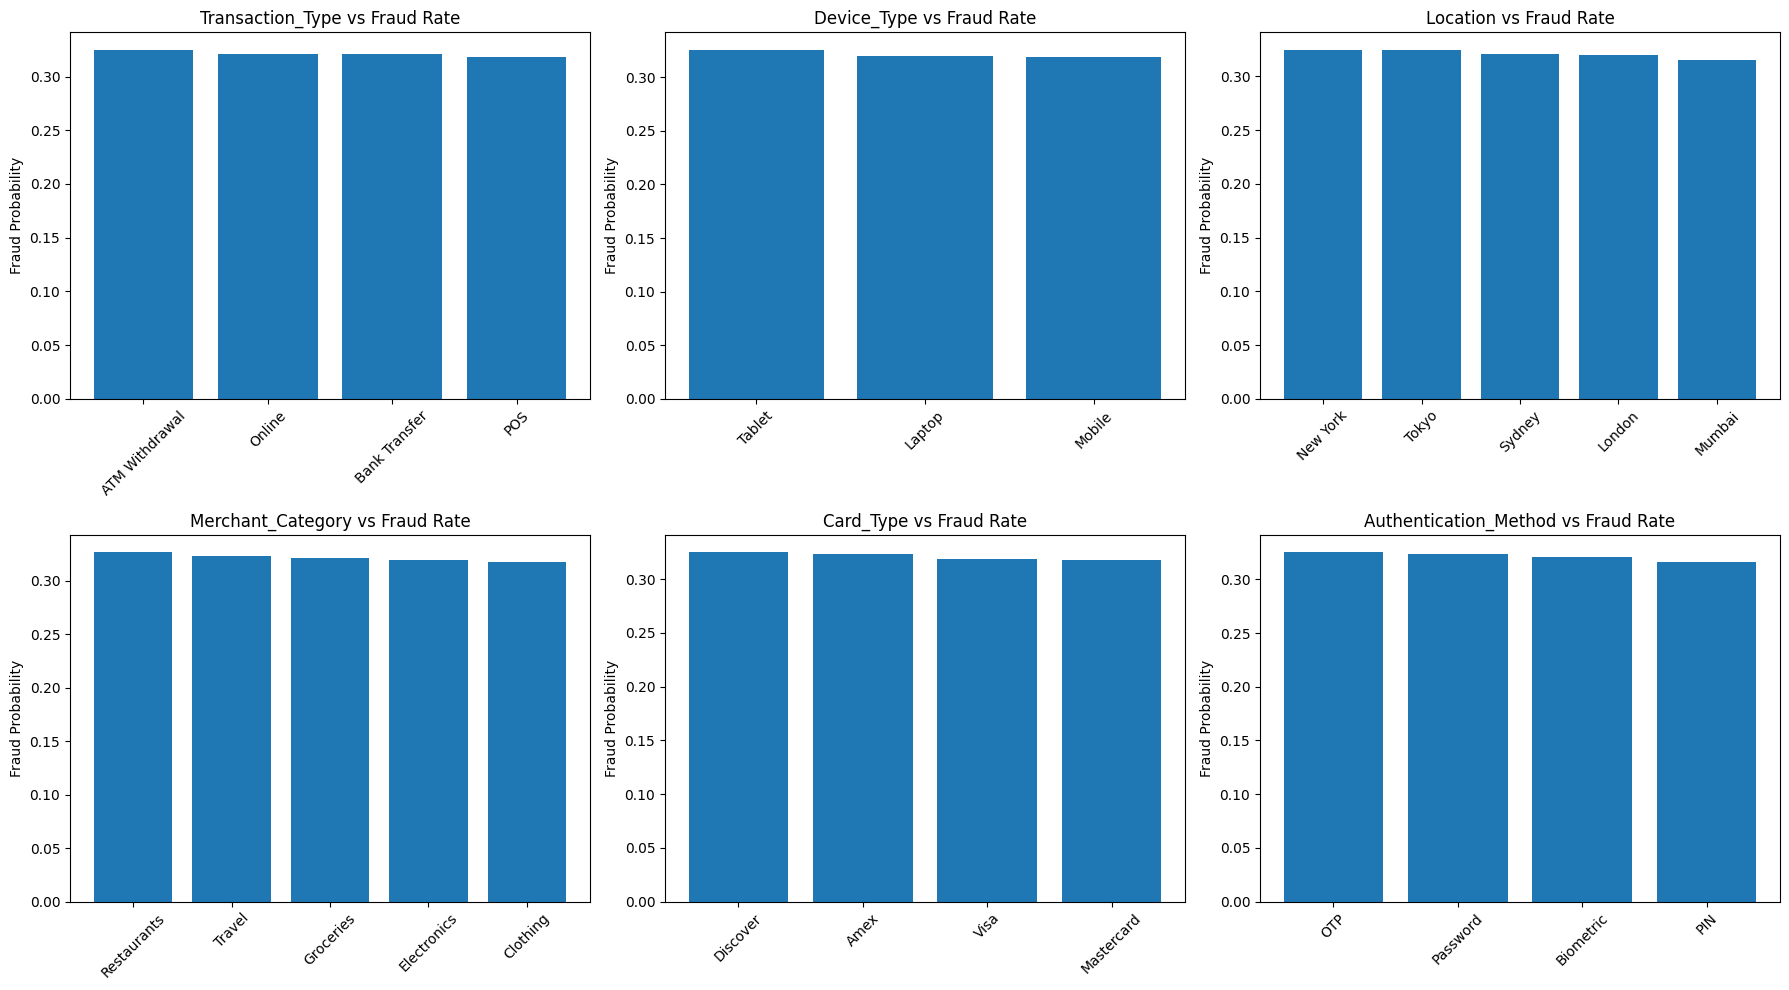

In [44]:
# categorical feature vs fraud rate
cols = 3
rows = math.ceil(len(categorical_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    
    fraud_rate = df.groupby(col)['Fraud_Label'].mean().sort_values(ascending=False)
    
    axes[i].bar(fraud_rate.index, fraud_rate.values)
    axes[i].set_title(f"{col} vs Fraud Rate")
    axes[i].set_ylabel("Fraud Probability")
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

* categorical features were measured aganist Fraud probability to remove size bias and directly measure risk as number of fraud cases per category can be misleading.  

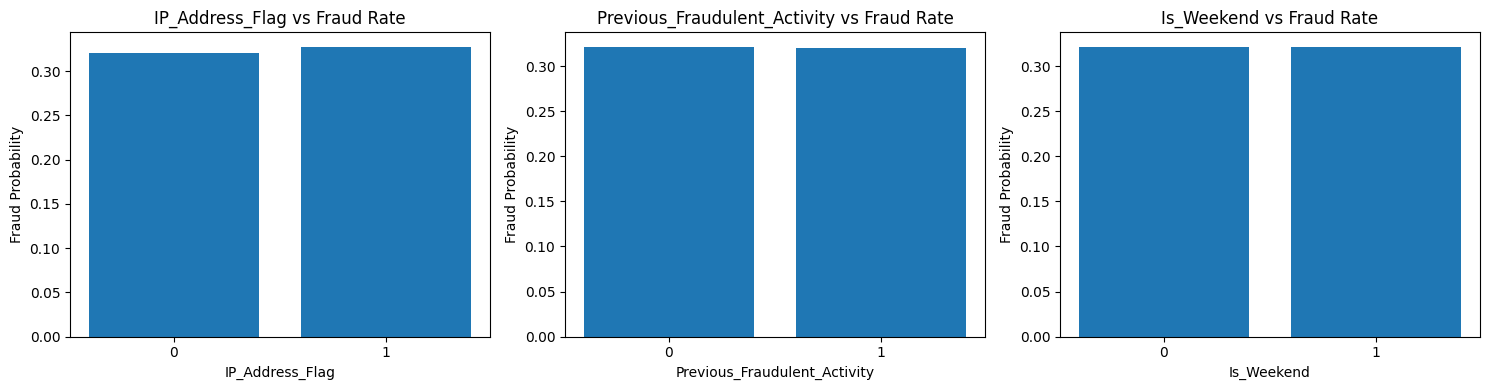

In [45]:
# Define binary features to compare between fraud and non-fraud

binary_features = [
    'IP_Address_Flag',
    'Previous_Fraudulent_Activity',
    'Is_Weekend'
]

cols = 3
rows = math.ceil(len(binary_features) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    
    fraud_rate = df.groupby(col)['Fraud_Label'].mean()
    
    axes[i].bar(fraud_rate.index.astype(str), fraud_rate.values)
    axes[i].set_title(f"{col} vs Fraud Rate")
    axes[i].set_ylabel("Fraud Probability")
    axes[i].set_xlabel(col)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Multivariate Analysis

In [46]:
# Select numeric features only
numeric_df = df.select_dtypes(include=['int64', 'float64']).copy()

In [47]:
# Compute correlation matrix for numeric features
corr_matrix = numeric_df.corr()

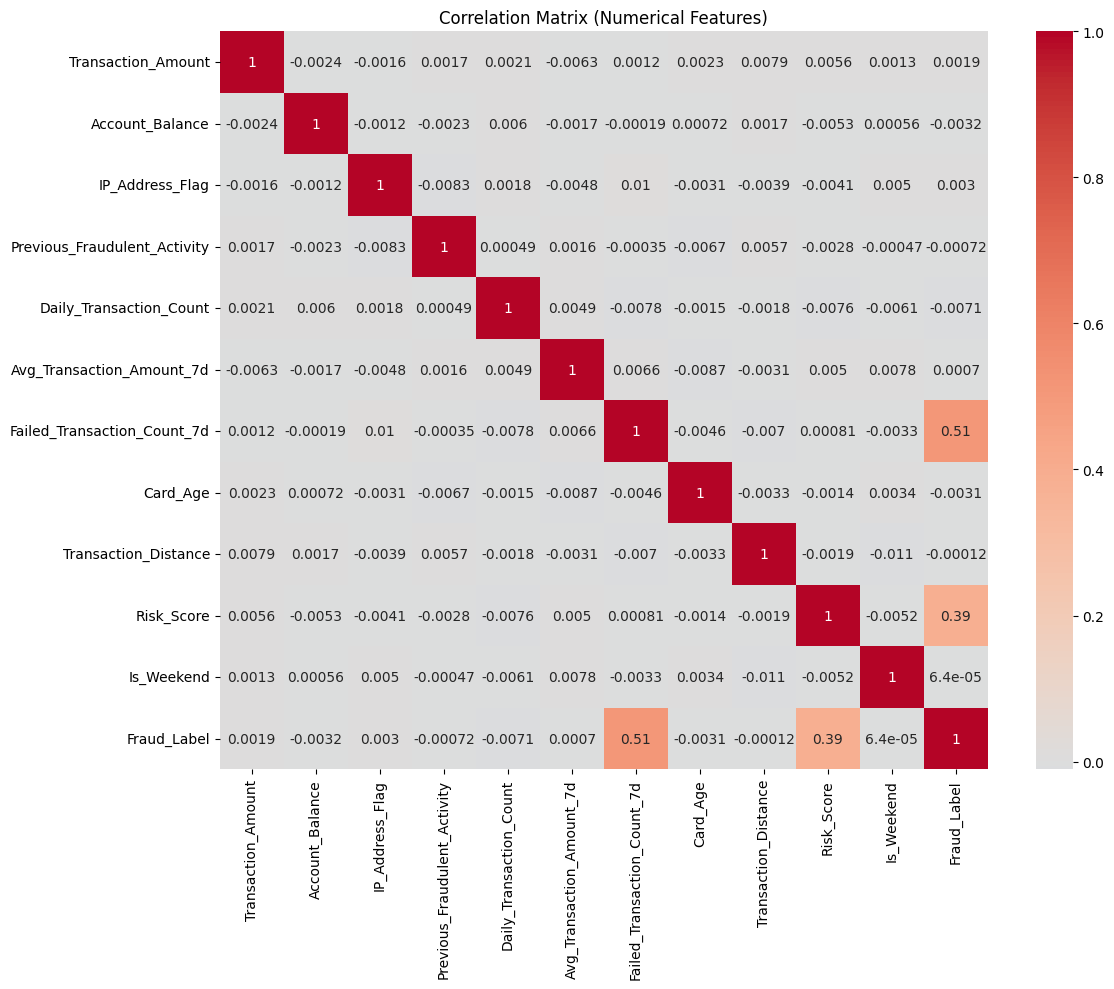

In [48]:
# Heatmap of correlation matrix to detect redundancy
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()


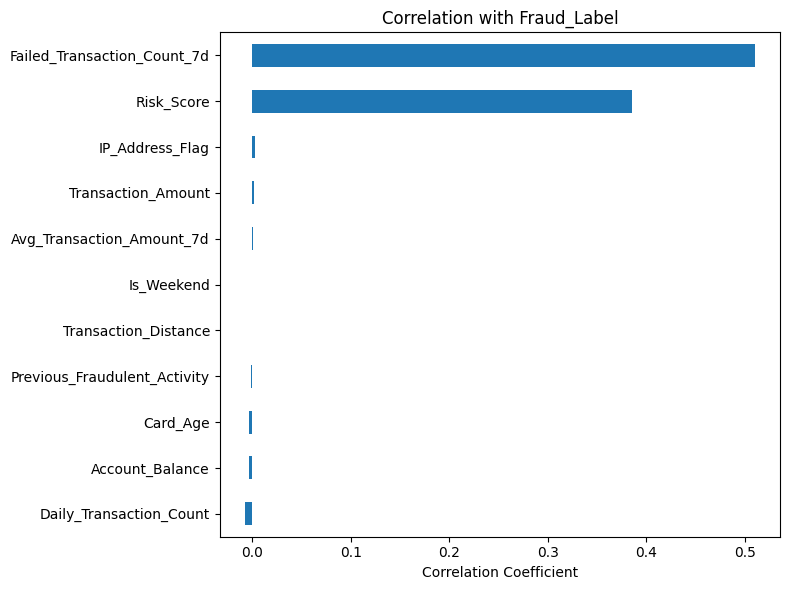

In [49]:
# Correlation with target variable
target_corr = corr_matrix['Fraud_Label'].drop('Fraud_Label').sort_values(ascending=False)

plt.figure(figsize=(8, 6))
target_corr.plot(kind='barh')
plt.title("Correlation with Fraud_Label")
plt.xlabel("Correlation Coefficient")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [50]:
# Interaction Patterns between top correlated features and target variable

def plot_interaction(x_feature, y_feature):
    
    plt.figure(figsize=(6,5))
    
    fraud_0 = df[df['Fraud_Label'] == 0]
    fraud_1 = df[df['Fraud_Label'] == 1]
    
    plt.scatter(
        fraud_0[x_feature],
        fraud_0[y_feature],
        alpha=0.2,
        s=10,
        label="Non-Fraud"
    )
    
    plt.scatter(
        fraud_1[x_feature],
        fraud_1[y_feature],
        alpha=0.2,
        s=10,
        label="Fraud"
    )
    
    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{x_feature} vs {y_feature}")
    plt.legend()
    plt.tight_layout()
    plt.show()

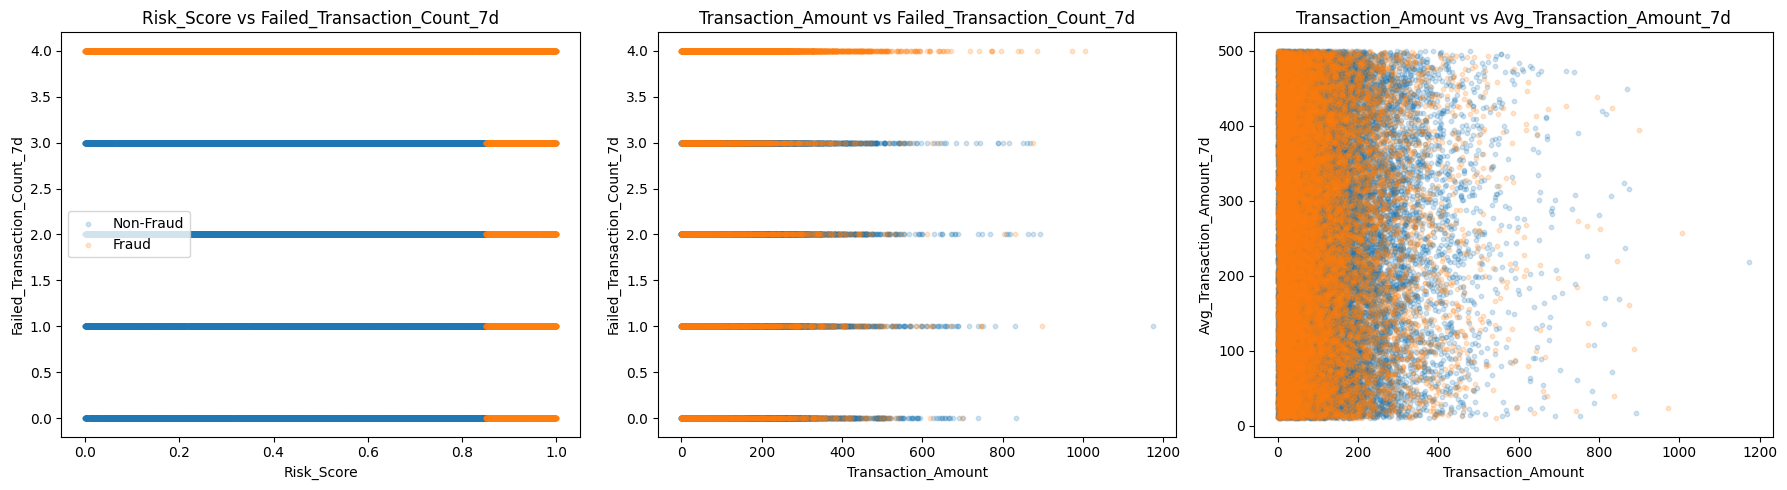

In [ ]:
# Plot selected two-feature interactions coloured by Fraud_Label
# Blue = Non-Fraud (0), Orange = Fraud (1)

# Define feature pairs to explore relationships between key variables
pairs = [
    ('Risk_Score', 'Failed_Transaction_Count_7d'),
    ('Transaction_Amount', 'Failed_Transaction_Count_7d'),
    ('Transaction_Amount', 'Avg_Transaction_Amount_7d')
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loop through each subplot and feature pair
for ax, (x, y) in zip(axes, pairs):
    for label, color in [(0, '#1f77b4'), (1, '#ff7f0e')]:
        subset = df[df['Fraud_Label'] == label]
        ax.scatter(subset[x], subset[y], s=10, alpha=0.2, color=color)
    
    ax.set(xlabel=x, ylabel=y, title=f"{x} vs {y}")

axes[0].legend(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

Fraud cases cluster more densely in regions with higher failed transaction counts and elevated risk scores, indicating that recent behavioural anomalies are strong indicators of fraud. suggests that fraud detection relies on interactions between features, rather than any single variable in isolation, supporting the use of non-linear models.

### Target Visualisation

Fraud_Label
0    33933
1    16067
Name: count, dtype: int64
Fraud_Label
0    67.866
1    32.134
Name: proportion, dtype: float64


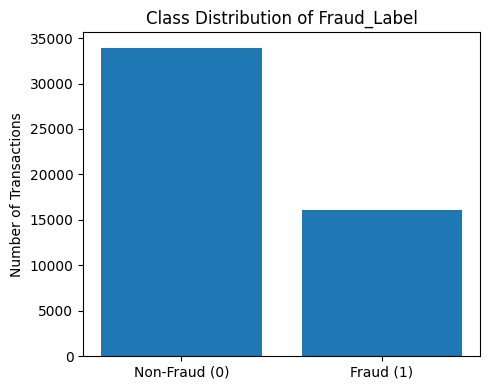

In [52]:
# Target Variable distribution
# Check Class distribution
fraud_counts = df['Fraud_Label'].value_counts()
fraud_percent = df['Fraud_Label'].value_counts(normalize=True) * 100

print(fraud_counts)
print(fraud_percent)

# Visual
counts = df['Fraud_Label'].value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(['Non-Fraud (0)', 'Fraud (1)'], counts.values)
plt.ylabel("Number of Transactions")
plt.title("Class Distribution of Fraud_Label")
plt.tight_layout()
plt.show()


### Documentation
* Target Distribution

The target variable (Fraud_Label) exhibits a fraud prevalence of approximately 32%, indicating an imbalanced classification problem. Imbalance mitigation techniques will be applied.

* Univariate Insight: Continous features were sectioned into 3 (Monetary features, Behavioural features and risk_score) because they measure different phenomena and operate on different scales. visualised using histogram for skewness and boxplot for outliers

Monetary Features: Transaction amount appear positively skewed with transaction behaviour being dominated by low-value transactions and extreme infrequent cases of high-value transactions. The presence of outliers suggests that transformation Log transformation will be required to compress extreme values. Account balance on the other hand indicates an approximately symmetric distribution without heavy tails. no transformation would be required. 

Behavioural Features: Most behavioural are uniformly distributed rather than naturally skewed and there is no evidence of extreme outliers within these variables. No transformations are required at this stage for these variables.

Risk_Score Feature: bounded between 0 and 1 and exhibits an approximately uniform distribution across this interval. There is no dominance of low-risk or high-risk observations.

Categorical Variables: Stable representation across levels. The uniformity across categorical variables suggests that predictive signal, if present, will arise from their interaction with other features.

* Bivariate Insight

Continous Features vs Fraud Label:


Categorical Features vs fraud_Label: categorical features were measured aganist Fraud probability to remove size bias and directly measure risk as number of fraud cases per category can be misleading. Fraud probability is remarkably consistent across all categorical levels as no category exhibits a meaningful elevation in fraud risk.

* Multivariate Insight

Two features show meaningful positive correlation with fraud - Failed_Transaction_Count and Risk_Score. All other numerical variables exhibit near-zero correlation with the target. No pair of predictor variables demonstrates high inter-correlation (>0.8), meaning that there is no severe multicollinearity concerns







# Feature Engineering

In [53]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label', 'Month'],
      dtype='str')

Merchant_Category
Clothing       0.317054
Electronics    0.319273
Groceries      0.321090
Restaurants    0.326283
Travel         0.323015
Name: Fraud_Label, dtype: float64


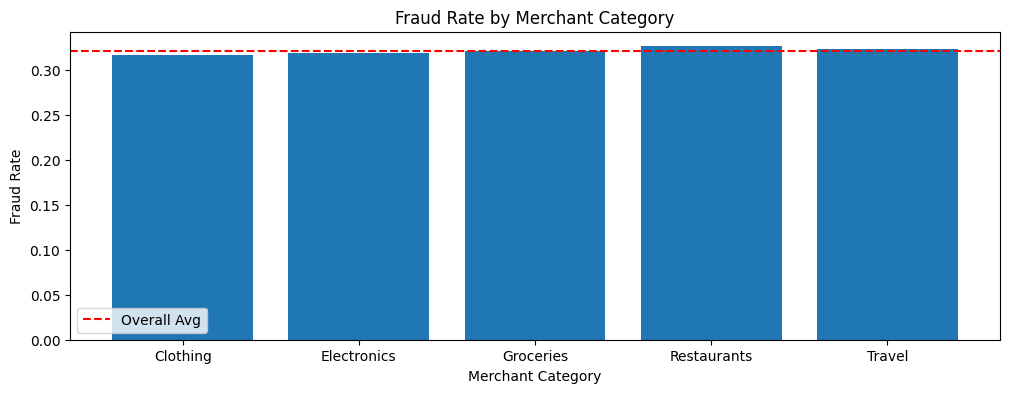

In [54]:
# Fraud rate by MERCHANT_CATEGORY
fraud_by_merchant_category = df.groupby('Merchant_Category')['Fraud_Label'].mean()

print(fraud_by_merchant_category)

# Visualize fraud rate by MERCHANT_CATEGORY 
plt.figure(figsize=(12, 4))
plt.bar(fraud_by_merchant_category.index, fraud_by_merchant_category.values)
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Merchant Category')

# Overall average fraud rate
plt.axhline(
    y=df['Fraud_Label'].mean(),
    color='r',
    linestyle='--',
    label='Overall Avg'
)

plt.legend()
plt.show()

Fraud rates are broadly consistent across merchant categories, with only minor variation around the overall average.

In [55]:
# create a time gap feature ie time since last transaction for each user
df = df.sort_values(by=['User_ID', 'Timestamp'])
df['Time_Since_Last_Transaction'] = df.groupby('User_ID')['Timestamp'].diff().dt.total_seconds()

# replace NaN values in time_since_last_transaction with zero (for first transaction of each user)
df['Time_Since_Last_Transaction'] = df['Time_Since_Last_Transaction'].fillna(0)



In [ ]:
# Analyse fraud rate based on time since last transaction

# Bin continuous time gaps into meaningful intervals for interpretation
df['time_gap_bin'] = pd.cut(
				df['Time_Since_Last_Transaction'],
				bins=[-1, 0, 60, 300, 600, 1800, np.inf],
				labels=['0s', '1-60s', '1-5min', '5-10min', '10-30min', '>30min']
)

fraud_by_time_gap = df.groupby('time_gap_bin')['Fraud_Label'].mean()

print(fraud_by_time_gap)

time_gap_bin
0s          0.319389
1-60s       0.000000
1-5min      0.500000
5-10min     0.200000
10-30min    0.400000
>30min      0.321769
Name: Fraud_Label, dtype: float64


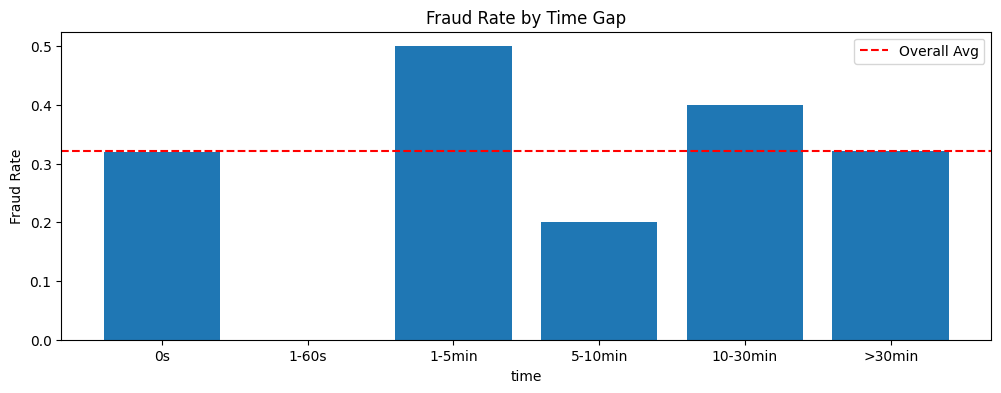

In [ ]:
# Visualise fraud rate across different time gap intervals

plt.figure(figsize=(12, 4))
plt.bar(fraud_by_time_gap.index, fraud_by_time_gap.values)
plt.xlabel('time')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Time Gap')

# Plot overall average fraud rate as a reference line
plt.axhline(
    y=df['Fraud_Label'].mean(),
    color='r',
    linestyle='--',
    label='Overall Avg'
)

plt.legend()
plt.show()

Fraud rates are highest for short time gaps between transactions, particularly within 1–5 minutes, suggesting that rapid successive activity is a strong fraud signal.

In [58]:
# Extract time-based features from Timestamp
df['Hour'] = df['Timestamp'].dt.hour
df['Month'] = df['Timestamp'].dt.month
df['Day_of_Week'] = df['Timestamp'].dt.dayofweek  # 0=Monday

Day_of_Week
0    0.323425
1    0.315849
2    0.314278
3    0.326967
4    0.318646
5    0.319091
6    0.331291
Name: Fraud_Label, dtype: float64


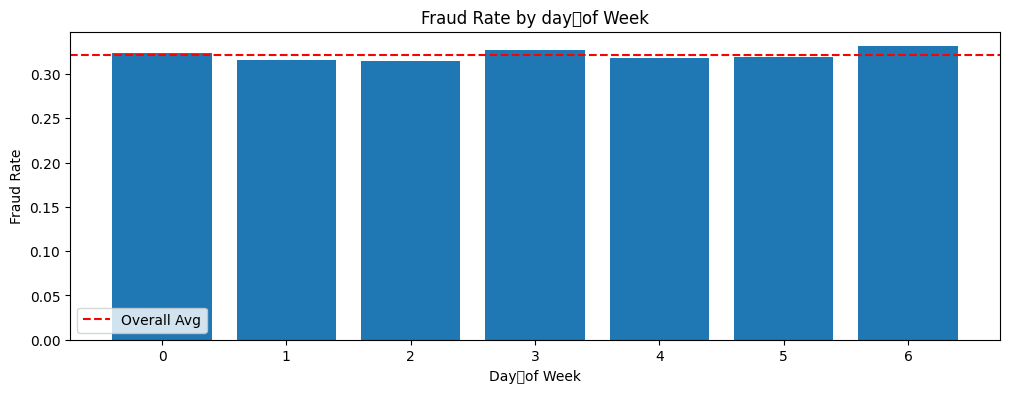

In [60]:
# Fraud rate by day of week
fraud_by_day = df.groupby('Day_of_Week')['Fraud_Label'].mean()

print(fraud_by_day)

#	Visualize fraud rate by day of week
plt.figure(figsize=(12, 4))
plt.bar(fraud_by_day.index, fraud_by_day.values)
plt.xlabel('Day	of Week')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by day	of Week')

# Overall average fraud rate
plt.axhline(
    y=df['Fraud_Label'].mean(),
    color='r',
    linestyle='--',
    label='Overall Avg'
)

plt.legend()
plt.show()

Fraud rates remain relatively stable across all days of the week, with only minor fluctuations around the overall average. This indicates that day-of-week effects are weak and not a strong standalone predictor of fraud.

Hour
0     0.322164
1     0.304108
2     0.317865
3     0.319332
4     0.314272
5     0.308066
6     0.320994
7     0.321146
8     0.318896
9     0.328500
10    0.326190
11    0.328182
12    0.319039
13    0.330439
14    0.326129
15    0.327421
16    0.324723
17    0.325156
18    0.325901
19    0.314218
20    0.331268
21    0.287234
22    0.337637
23    0.332332
Name: Fraud_Label, dtype: float64


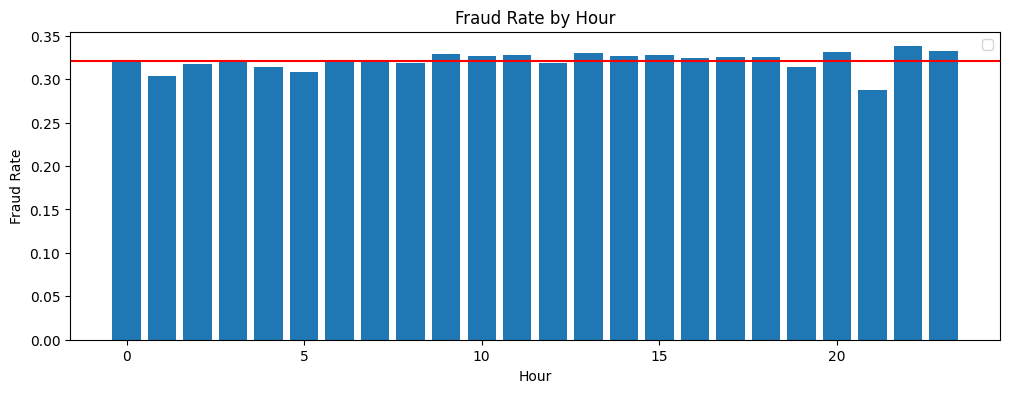

In [61]:
# Fraud rate by hour
fraud_by_hour = df.groupby('Hour')['Fraud_Label'].mean()

print(fraud_by_hour)

plt.figure(figsize=(12, 4))
plt.bar(fraud_by_hour.index, fraud_by_hour.values)
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Hour')

# Overall average fraud rate
plt.axhline(
    y=df['Fraud_Label'].mean(),
    color='r',
   
)

plt.legend()
plt.show()


Fraud rates are relatively consistent across hours, with only slight increases during late evening and night periods. that hour of day alone is not a strong predictor.

In [62]:
# Create new features based on the knowledge of our feature engineeringinsights
df['High_Fraud_time_gap'] = df['time_gap_bin'].isin(['1-5m', '10-30min']).astype(int)
df['High_fraud_hour'] = df['Hour'].isin([20, 22, 23]).astype(int)
df['High_Fraud_days_of_week'] = df['Day_of_Week'].isin([3, 6]).astype(int)

##### Ratio Features

In [65]:
# Failure rate of transactions in the past 7 days
# High failure rate may indicate account issues or fraudulent activity

df['Failure_Rate_7d'] = df['Failed_Transaction_Count_7d'] / (df['Daily_Transaction_Count'])

In [67]:
# High Risk Behaviour Flag
# Flags transactions with multiple recent failures and high risk score as high risk behaviour
df['High_Risk_Behaviour'] = (
    (df['Failed_Transaction_Count_7d'] >= 3) &
    (df['Risk_Score'] > 0.7)
).astype(int)

In [68]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Month,Time_Since_Last_Transaction,time_gap_bin,Hour,Day_of_Week,High_Fraud_time_gap,High_fraud_hour,High_Fraud_days_of_week,Failure_Rate_7d,High_Risk_Behaviour
47834,TXN_36059,USER_1000,69.02,Online,2023-02-21 10:25:00,36077.57,Tablet,London,Groceries,0,...,2,0.0,0s,10,1,0,0,0,0.666667,0
28102,TXN_28650,USER_1000,191.87,Online,2023-04-26 23:17:00,4201.83,Laptop,Tokyo,Electronics,0,...,4,5575920.0,>30min,23,2,0,1,0,0.285714,0
13089,TXN_40117,USER_1000,64.78,Online,2023-09-01 20:09:00,25291.69,Tablet,London,Clothing,0,...,9,11047920.0,>30min,20,4,0,1,0,0.200000,0
21475,TXN_13680,USER_1000,383.60,Bank Transfer,2023-10-29 03:47:00,53558.88,Laptop,Mumbai,Clothing,0,...,10,4952280.0,>30min,3,6,0,0,1,0.125000,0
41209,TXN_21630,USER_1000,39.41,Bank Transfer,2023-12-03 06:43:00,70995.83,Laptop,Mumbai,Clothing,0,...,12,3034560.0,>30min,6,6,0,0,1,0.500000,0


In [69]:
df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Timestamp', 'Account_Balance', 'Device_Type', 'Location',
       'Merchant_Category', 'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label', 'Month', 'Time_Since_Last_Transaction',
       'time_gap_bin', 'Hour', 'Day_of_Week', 'High_Fraud_time_gap',
       'High_fraud_hour', 'High_Fraud_days_of_week', 'Failure_Rate_7d',
       'High_Risk_Behaviour'],
      dtype='str')

In [70]:
#  Drop Irelevant features columns was use for feature	engineering
df = df.drop(columns=[
				'time_gap_bin',
				'Hour',
    'Day_of_Week',
    'User_ID',
    'Transaction_ID'
])

In [ ]:
# check for multicollinearity using VIF
numeric_columns = df.drop(columns=['Fraud_Label'])

# Keep only numeric columns
numeric_columns= numeric_columns.select_dtypes(include=['int64', 'float64'])

# Compute VIF for each feature to quantify multicollinearity
vif_data = pd.DataFrame({
    "Feature": numeric_columns.columns,
    "VIF": [variance_inflation_factor(numeric_columns.values, i)
            for i in range(numeric_columns.shape[1])]
}).sort_values(by="VIF", ascending=False)

print(vif_data)



                         Feature       VIF
4        Daily_Transaction_Count  5.761412
6    Failed_Transaction_Count_7d  5.094163
9                     Risk_Score  4.470091
5      Avg_Transaction_Amount_7d  3.776266
1                Account_Balance  3.630807
7                       Card_Age  3.588188
8           Transaction_Distance  3.573658
15               Failure_Rate_7d  2.879569
0             Transaction_Amount  1.943939
11   Time_Since_Last_Transaction  1.725842
16           High_Risk_Behaviour  1.678442
10                    Is_Weekend  1.405495
14       High_Fraud_days_of_week  1.379566
13               High_fraud_hour  1.137279
3   Previous_Fraudulent_Activity  1.105127
2                IP_Address_Flag  1.050897
12           High_Fraud_time_gap  1.000504


In [72]:
# Remove features with high VIF > 5 and recalculate VIF

numeric_columns = df.drop(columns=['Fraud_Label', 'Daily_Transaction_Count'])

# Keep only numeric columns
numeric_columns= numeric_columns.select_dtypes(include=['int64', 'float64'])

vif_data = pd.DataFrame({
    "Feature": numeric_columns.columns,
    "VIF": [variance_inflation_factor(numeric_columns.values, i)
            for i in range(numeric_columns.shape[1])]
}).sort_values(by="VIF", ascending=False)
                                                    
print(vif_data)

                         Feature       VIF
8                     Risk_Score  4.279973
5    Failed_Transaction_Count_7d  4.119270
4      Avg_Transaction_Amount_7d  3.648467
1                Account_Balance  3.513750
6                       Card_Age  3.480442
7           Transaction_Distance  3.464751
0             Transaction_Amount  1.927391
14               Failure_Rate_7d  1.922702
10   Time_Since_Last_Transaction  1.714951
15           High_Risk_Behaviour  1.656582
9                     Is_Weekend  1.400762
13       High_Fraud_days_of_week  1.376086
12               High_fraud_hour  1.136215
3   Previous_Fraudulent_Activity  1.103631
2                IP_Address_Flag  1.050375
11           High_Fraud_time_gap  1.000495


Following feature engineering, multicollinearity was assessed using Variance Inflation Factor (VIF). Structural dependencies arising from time dummy variables and engineered weekend interactions were resolved. The final predictor set exhibits acceptable VIF values (all < 5), indicating no significant multicollinearity concerns for logistic regression modelling.

In [73]:
df.columns

Index(['Transaction_Amount', 'Transaction_Type', 'Timestamp',
       'Account_Balance', 'Device_Type', 'Location', 'Merchant_Category',
       'IP_Address_Flag', 'Previous_Fraudulent_Activity',
       'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d',
       'Failed_Transaction_Count_7d', 'Card_Type', 'Card_Age',
       'Transaction_Distance', 'Authentication_Method', 'Risk_Score',
       'Is_Weekend', 'Fraud_Label', 'Month', 'Time_Since_Last_Transaction',
       'High_Fraud_time_gap', 'High_fraud_hour', 'High_Fraud_days_of_week',
       'Failure_Rate_7d', 'High_Risk_Behaviour'],
      dtype='str')

## Defining Final Feature Set for Modeling

In [ ]:
# sort timestamp to ensure temporal integrity for train-test split (prevents data leakage in time-based split)
df = df.sort_values(by='Timestamp').reset_index(drop=True)

# Separete Features and Target Variable
X = df.drop(columns=['Fraud_Label'])
y = df['Fraud_Label']


In [75]:
df.head()

,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,...,Risk_Score,Is_Weekend,Fraud_Label,Month,Time_Since_Last_Transaction,High_Fraud_time_gap,High_fraud_hour,High_Fraud_days_of_week,Failure_Rate_7d,High_Risk_Behaviour
0,72.54,ATM Withdrawal,2023-01-01 00:01:00,60673.36,Mobile,New York,Travel,0,0,8,...,0.7218,0,0,1,0.0,0,0,1,0.000000,0
1,78.68,Bank Transfer,2023-01-01 00:42:00,75204.02,Tablet,Mumbai,Travel,0,0,5,...,0.3373,0,0,1,0.0,0,0,1,0.000000,0
2,63.97,POS,2023-01-01 00:46:00,44124.04,Tablet,Mumbai,Restaurants,0,0,3,...,0.9262,0,1,1,0.0,0,0,1,1.000000,1
3,257.68,POS,2023-01-01 01:06:00,61383.97,Tablet,Tokyo,Groceries,0,0,2,...,0.8859,0,1,1,0.0,0,0,1,2.000000,1
4,99.42,ATM Withdrawal,2023-01-01 01:11:00,88959.44,Laptop,Tokyo,Travel,0,0,7,...,0.0152,0,1,1,0.0,0,0,1,0.571429,0


In [76]:
# Numeric features list for scaling and modeling
numeric_features = (
    X.select_dtypes(include=['int64', 'float64'])
     .columns
     .tolist()
)

# Categorical features list for encoding
categorical_features = (
    X.select_dtypes(include=['object', 'category', 'string'])
     .columns
     .tolist()
)

print("Numeric Features:")
print(numeric_features)

print("Categorical Features:")
print(categorical_features)


Numeric Features:
['Transaction_Amount', 'Account_Balance', 'IP_Address_Flag', 'Previous_Fraudulent_Activity', 'Daily_Transaction_Count', 'Avg_Transaction_Amount_7d', 'Failed_Transaction_Count_7d', 'Card_Age', 'Transaction_Distance', 'Risk_Score', 'Is_Weekend', 'Time_Since_Last_Transaction', 'High_Fraud_time_gap', 'High_fraud_hour', 'High_Fraud_days_of_week', 'Failure_Rate_7d', 'High_Risk_Behaviour']
Categorical Features:
['Transaction_Type', 'Device_Type', 'Location', 'Merchant_Category', 'Card_Type', 'Authentication_Method']


## Test Split and Pipeline for Modeling

In [77]:
df = df.sort_values("Timestamp")
# Train/Test Split. Test set will remain untouched until final evaluation 
X = df.drop(columns=['Fraud_Label'])
y = df['Fraud_Label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False # maintain temporal integrity for train-test split,
)

In [78]:
# Define Columns to drop based on VIF analysis and domain knowledge
columns_to_drop = [
    'Is_Night',
    'Weekend_Risk',
    'Daily_Transaction_Count',
    'Transaction_ID',
    'User_ID',
    'Risk_Score'
]

In [79]:
# Remove dropped columns from feature lists
X_temp = X_train.drop(columns=columns_to_drop, errors='ignore')

# Identify numeric and categorical features in training set
numeric_features = X_temp.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_temp.select_dtypes(include=['object', 'category', 'string']).columns.tolist()


In [80]:
# Column dropper transformer to remove features 
drop_transformer = FunctionTransformer(
    lambda X: X.drop(columns=columns_to_drop, errors='ignore'),
    validate=False
)


### Preprocessing Pipeline

In [ ]:
# Define preprocessing pipeline for feature transformation

# Apply different transformations to different feature groups:
# - Log transform for Transaction_Amount to reduce skewness
# - Standard scaling for numerical features to normalise distributions
# - One-hot encoding for categorical features to convert them into numeric format

preprocessor = ColumnTransformer(
    transformers=[
        ('log_amount',
         FunctionTransformer(np.log1p, validate=False),
         ['Transaction_Amount']),

        ('num',
         StandardScaler(),
         numeric_features),

        ('cat',
         OneHotEncoder(drop='first', handle_unknown='ignore'),
         categorical_features)
    ],
    remainder='drop' # drop any columns not explicitly transformed
)

In [ ]:
# Remove Transaction_Amount from numeric features list
# It is already handled separately via log transformation in the pipeline
if 'Transaction_Amount' in numeric_features:
    numeric_features.remove('Transaction_Amount')

### Model Pipeline Creation

In [ ]:
# Dummy Classifier as baseline model

# Build pipeline:
# 1. Drop unnecessary columns
# 2. Apply preprocessing (log transform, scaling, encoding)
# 3. Fit DummyClassifier to establish baseline performance (predicts most frequent class)

dummy_pipeline = Pipeline([
    ('drop_cols', drop_transformer),
    ('preprocess', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])

In [84]:
# Logistic Regression Pipeline
logreg_pipeline = Pipeline([
    ('drop_cols', drop_transformer),
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])
# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('drop_cols', drop_transformer),
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        n_estimators=200,
        random_state=42
    ))
])

# XGBoost Using scale_pos_weight to handle class imbalance
# Compute scale_pos_weight for XGBoost based on class imbalance in training data

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

# XGBoost pipeline

xgb_pipeline = Pipeline([
    ('drop_cols', drop_transformer),
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

 # Support Vector Machine Pipeline
svm_pipeline = Pipeline([
     ('drop_cols', drop_transformer),
     ('preprocess', preprocessor),
     ('model', SVC(
         kernel='rbf',
         C=1.0,
         gamma='scale',
         class_weight='balanced',
         probability=True,   # needed for ROC-AUC
         random_state=42
     ))
 ])

,Raw Count,Raw %,Effective Weight (sum),Effective Weight %
Class,,,,
Non-Fraud (0),27161,67.9,20000.0,50.0
Fraud (1),12839,32.1,20000.0,50.0


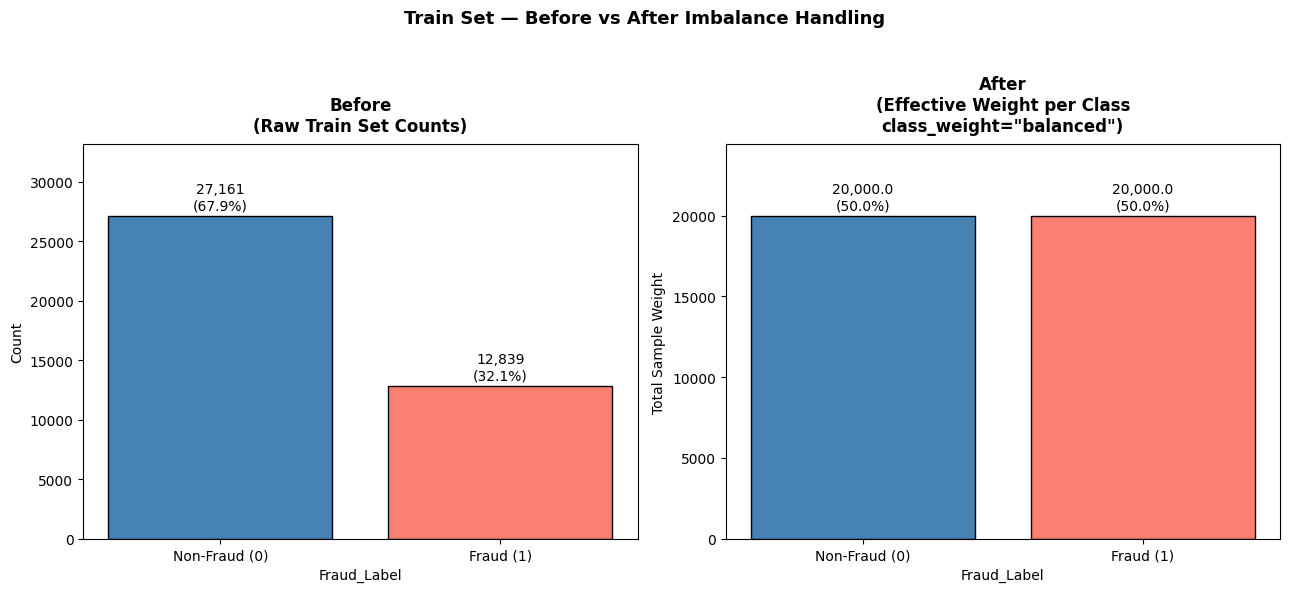

Before: {0: np.int64(27161), 1: np.int64(12839)}
After (total weight per class): {0: 20000.0, 1: 20000.0}


In [98]:

# Train Set: Before vs After Imbalance Handling
# Strategy: class_weight='balanced' (LR, RF, SVM) + scale_pos_weight (XGBoost)
# No resampling is applied — weights adjust the model's learning, not the data counts.

from sklearn.utils.class_weight import compute_sample_weight

# --- Before: raw class counts ---
before_counts = y_train.value_counts().sort_index()

# --- After: effective weighted contribution per class ---
# compute_sample_weight mirrors what class_weight='balanced' does internally
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

after_weights = pd.Series(sample_weights, index=y_train.index).groupby(y_train).sum()
after_weights = after_weights.sort_index()

# --- Summary table ---
summary = pd.DataFrame({
    'Class':           ['Non-Fraud (0)', 'Fraud (1)'],
    'Raw Count':       before_counts.values,
    'Raw %':           (before_counts / before_counts.sum() * 100).round(2).values,
    'Effective Weight (sum)': after_weights.round(1).values,
    'Effective Weight %':     (after_weights / after_weights.sum() * 100).round(2).values,
})
display(summary.set_index('Class'))

# --- Side-by-side bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Left: before
bars0 = axes[0].bar(
    ['Non-Fraud (0)', 'Fraud (1)'],
    before_counts.values,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
axes[0].set_title('Before\n(Raw Train Set Counts)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Fraud_Label')
axes[0].set_ylim(top=before_counts.max() * 1.22)  # extra headroom for 2-line labels
for bar, val in zip(bars0, before_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + before_counts.max() * 0.01,
        f'{val:,}\n({val/before_counts.sum()*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

# Right: after (effective weights)
bars1 = axes[1].bar(
    ['Non-Fraud (0)', 'Fraud (1)'],
    after_weights.values,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
axes[1].set_title('After\n(Effective Weight per Class\nclass_weight="balanced")', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Total Sample Weight')
axes[1].set_xlabel('Fraud_Label')
axes[1].set_ylim(top=after_weights.max() * 1.22)  # extra headroom for 2-line labels
for bar, val in zip(bars1, after_weights.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + after_weights.max() * 0.01,
        f'{val:,.1f}\n({val/after_weights.sum()*100:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )

plt.suptitle('Train Set — Before vs After Imbalance Handling', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("Before:", dict(before_counts))
print("After (total weight per class):", {k: round(v, 1) for k, v in after_weights.items()})

The training data appears imbalanced, with non-fraud cases comprising the majority. After applying class weighting, both classes are given equal importance during model training, effectively balancing their influence without altering the data itself. This ensures the model pays equal attention to fraud cases, improving its ability to learn minority class patterns.

### Stratified K-Fold Cross Validation on Training Data Only

In [ ]:
# Define Stratified K-Fold cross-validation
# Preserves class distribution in each fold (important for imbalanced data)
# shuffle=False ensures temporal order is maintained (no data leakage)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=False
)

# Store all models in a dictionary for evaluation
models = {
    "Dummy": dummy_pipeline,
    "Logistic": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "SVM": svm_pipeline
}

for name, model in models.items():
    # Compute ROC-AUC across folds (measures ranking performance)
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=skf,
        scoring='roc_auc'
    )
    
    print(f"\n{name}")
    print("Mean CV ROC-AUC:", scores.mean())


Dummy
Mean CV ROC-AUC: 0.5

Logistic
Mean CV ROC-AUC: 0.8019548010523199

Random Forest
Mean CV ROC-AUC: 0.8774735843980949

XGBoost
Mean CV ROC-AUC: 0.874952253338608

SVM
Mean CV ROC-AUC: 0.8145005935902265


Tree-based models (Random Forest and XGBoost) achieved the highest ROC-AUC scores, indicating stronger ability to capture complex, non-linear fraud patterns. Logistic Regression and SVM perform moderately well but are less effective due to their more limited capacity to model feature interactions. The Dummy model confirms that predictive performance is driven by meaningful feature signals rather than class distribution.

In [86]:
# Fit the Random Forest model on the training data
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_cols', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...0021A37063E20>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments t

### Hyperparameter Tuning

In [87]:
#	Hyperparameter tuning for Random Forest using RandomizedSearchCV
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

# Use RandomizedSearchCV to find the best hyperparameters for the Random Forest model based on ROC-AUC score with 5-fold cross-validation
rf_tuned = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=5,                 
    n_jobs=-1,
    verbose=1,
    random_state=42
)

#	Fit the RandomizedSearchCV on the training data to find the best hyperparameters
rf_tuned.fit(X_train, y_train)

print("\nBest Parameters:")
# Print the best hyperparameters found by RandomizedSearchCV for the Random Forest model
for param, value in rf_tuned.best_params_.items():
    print(f"{param}: {value}")
    
print(f'')


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters:
model__n_estimators: 200
model__min_samples_split: 2
model__min_samples_leaf: 4
model__max_features: log2
model__max_depth: 20



In [88]:
#	Best ROC-AUC Score and best parameters from RandomizedSearchCV
best_rf = rf_tuned.best_estimator_

print(rf_tuned.best_params_)
print(rf_tuned.best_score_)

{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 20}
0.8796493390992992


In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.base import clone
import pandas as pd
import numpy as np

# -----------------------------
# BEFORE TUNING
# -----------------------------
rf_before = clone(rf_pipeline)

# Cross-validation (5-fold)
before_cv_scores = cross_val_score(
    rf_before,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit model
rf_before.fit(X_train, y_train)

# Predictions
y_pred_before = rf_before.predict(X_test)
y_proba_before = rf_before.predict_proba(X_test)[:, 1]

# -----------------------------
# AFTER TUNING
# -----------------------------
rf_after = rf_tuned.best_estimator_

# Cross-validation AGAIN on tuned model (IMPORTANT FIX)
after_cv_scores = cross_val_score(
    rf_after,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Fit tuned model
rf_after.fit(X_train, y_train)

# Predictions
y_pred_after = rf_after.predict(X_test)
y_proba_after = rf_after.predict_proba(X_test)[:, 1]

# -----------------------------
# COMPARISON TABLE
# -----------------------------
comparison_df = pd.DataFrame([
    {
        "Model Version": "Before Tuning",
        "CV ROC-AUC (Mean)": before_cv_scores.mean(),
        "CV ROC-AUC (Std)": before_cv_scores.std(),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba_before),
        "Test Accuracy": accuracy_score(y_test, y_pred_before),
        "Test Precision": precision_score(y_test, y_pred_before),
        "Test Recall": recall_score(y_test, y_pred_before),
        "Test F1": f1_score(y_test, y_pred_before),
    },
    {
        "Model Version": "After Tuning",
        "CV ROC-AUC (Mean)": after_cv_scores.mean(),
        "CV ROC-AUC (Std)": after_cv_scores.std(),
        "Test ROC-AUC": roc_auc_score(y_test, y_proba_after),
        "Test Accuracy": accuracy_score(y_test, y_pred_after),
        "Test Precision": precision_score(y_test, y_pred_after),
        "Test Recall": recall_score(y_test, y_pred_after),
        "Test F1": f1_score(y_test, y_pred_after),
    },
])

# Round results
comparison_df = comparison_df.round(4)

# Display
comparison_df

,Model Version,CV ROC-AUC (Mean),CV ROC-AUC (Std),Test ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1
0,Before Tuning,0.8775,0.0055,0.8850,0.8776,0.9434,0.6605,0.7770
1,After Tuning,0.8796,0.0040,0.8841,0.8789,0.8833,0.7200,0.7933


Hyperparameter tuning improves recall and F1-score, meaning more fraud cases are correctly identified. This comes at the cost of reduced precision, reflecting an increase in false positives. Overall, tuning shifts the model towards better fraud detection coverage.

In [90]:
#	predict probabilities for the test set using the best Random Forest model
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

In [91]:
# Evaluate performance on test set
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      6772
           1       0.88      0.72      0.79      3228

    accuracy                           0.88     10000
   macro avg       0.88      0.84      0.85     10000
weighted avg       0.88      0.88      0.88     10000

ROC-AUC Score: 0.8840835706616134


The model achieves strong overall performance (accuracy ≈ 0.88, ROC-AUC ≈ 0.88), with balanced precision across both classes. It performs very well in identifying non-fraud cases (recall = 0.95), while fraud detection is lower (recall = 0.72), indicating some missed fraud cases. The results reflect a reasonable trade-off, with the model favouring fewer false positives while still capturing the majority of fraudulent transactions.

Text(0.5, 1.0, 'Confusion Matrix')

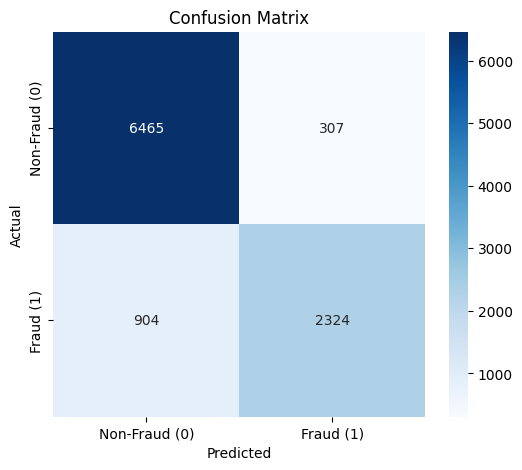

In [92]:
# display the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',	xticklabels=['Non-Fraud (0)', 'Fraud (1)'], yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.xlabel('Predicted')

plt.ylabel('Actual')
plt.title('Confusion Matrix')

The model correctly classifies most non-fraud transactions (6465) with relatively few false positives (307), indicating strong performance in avoiding unnecessary alerts. It also identifies a substantial number of fraud cases (2324), though a notable portion (904) are missed. This reflects a trade-off where the model prioritises precision and operational efficiency, but at the cost of some missed fraudulent transactions.

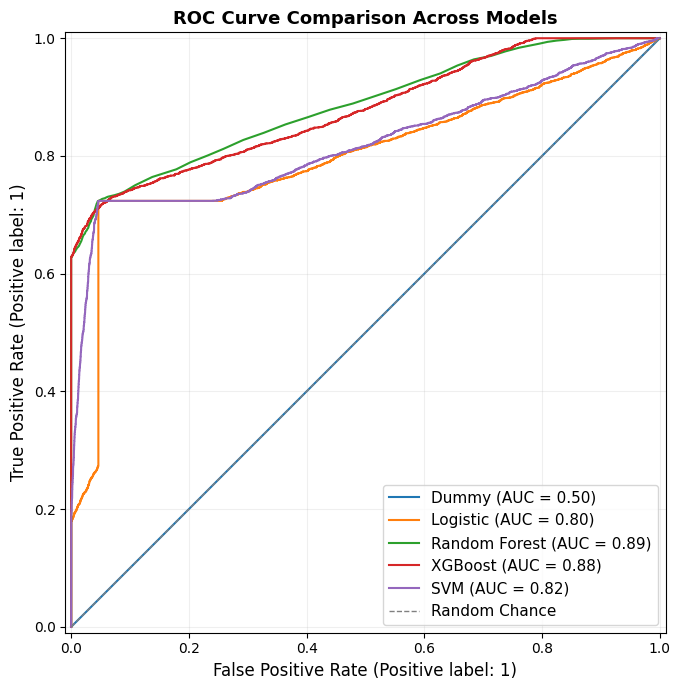

In [93]:
# Plot ROC curves for all candidate models in one professional chart
fig, ax = plt.subplots(figsize=(9, 7))

for model_name, model in models.items():
    # Clone to avoid shared-preprocessor state conflicts, then fit if needed
    clf = clone(model)
    try:
        clf.predict_proba(X_test)
    except (NotFittedError, AttributeError, ValueError):
        clf.fit(X_train, y_train)

    RocCurveDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        ax=ax,
        name=model_name,
    )

# Baseline diagonal for reference
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Random Chance")
ax.set_title("ROC Curve Comparison Across Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate (Positive label: 1)", fontsize=12)
ax.set_ylabel("True Positive Rate (Positive label: 1)", fontsize=12)
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

Random Forest and XGBoost achieve the highest ROC-AUC, indicating superior ability to distinguish fraud from non-fraud across thresholds. Logistic Regression and SVM perform moderately, while the Dummy model confirms no predictive power baseline. The results highlight the importance of non-linear models in capturing complex fraud patterns.

## Feature Importance Analysis
Production-grade feature importance with multiple validation methods


📊 Model Configuration:
   Total features: 35
   - 1 transformed amount (log)
   - 15 numeric features (scaled)
   - 19 categorical features (one-hot encoded)

🎯 TOP FEATURES FOR FRAUD DETECTION

Rank   Feature                                    Score        ±  Std Dev  
--------------------------------------------------------------------------------
1      Failed_Transaction_Count_7d                0.50341      0.11240     
2      Failure_Rate_7d                            0.12058      0.09424     
3      High_Risk_Behaviour                        0.09385      0.03411     
4      Transaction_Distance                       0.03304      0.00515     
5      Transaction_Amount (log)                   0.03300      0.00560     
6      Avg_Transaction_Amount_7d                  0.03292      0.00496     
7      Account_Balance                            0.03212      0.00522     
8      Card_Age                                   0.03084      0.00517     
9      Time_Since_Last_Transaction     

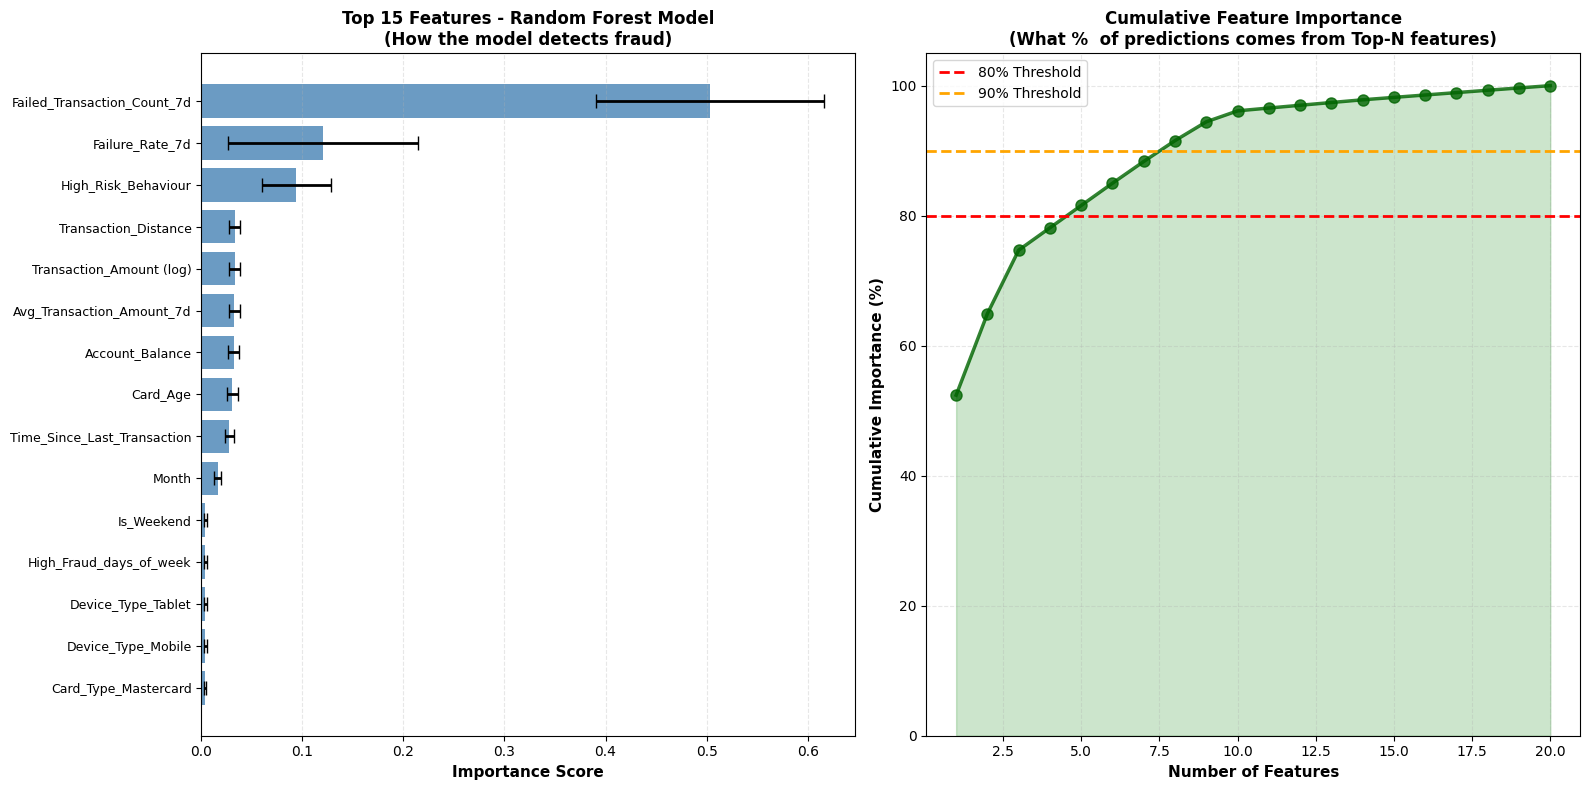


✅ Visualization saved: feature_importance.png

📋 WHAT TO TELL YOUR STAKEHOLDERS/CLIENTS

EXECUTIVE SUMMARY:
─────────────────

Our fraud detection model identifies fraud using 3 PRIMARY signals:

1. Failed_Transaction_Count_7d              (Score: 50.3%)
   → Indicates pattern of transaction failures

2. Failure_Rate_7d                          (Score: 12.1%)
   → Shows unusual failure rate behavior

3. High_Risk_Behaviour                      (Score: 9.4%)
   → Combined high-risk indicators

INTERPRETATION:
───────────────
• The LEFT CHART shows which patterns the model learned to detect fraud
• Features at the top = strongest fraud signals
• Error bars show how consistent these patterns are

• The RIGHT CHART shows that just the top 6 features explain 80% of predictions
  = Model is FOCUSED and EXPLAINABLE ✓

KEY TAKEAWAY:
─────────────
"Our model is built on clear, understandable fraud patterns that align with
real-world fraud behavior. It's not a black box - we can explain every d

In [94]:


# ============================================================================
# FEATURE IMPORTANCE ANALYSIS - PRODUCTION GRADE
# ============================================================================

# Step 1: Build feature names from preprocessor
preprocessor_obj = best_rf.named_steps['preprocess']

feature_names = []
feature_names.append('Transaction_Amount (log)')

numeric_feats_clean = [col for col in numeric_features if col != 'Transaction_Amount']
feature_names.extend(numeric_feats_clean)

cat_encoder = preprocessor_obj.named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names.extend(cat_names)

print(f"\n📊 Model Configuration:")
print(f"   Total features: {len(feature_names)}")
print(f"   - 1 transformed amount (log)")
print(f"   - {len(numeric_feats_clean)} numeric features (scaled)")
print(f"   - {len(cat_names)} categorical features (one-hot encoded)")

# Step 2: Extract Random Forest Importance (most important step)
rf_model = best_rf.named_steps['model']
importances = rf_model.feature_importances_
std_importances = np.std([tree.feature_importances_ for tree in rf_model.estimators_], axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Std': std_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("🎯 TOP FEATURES FOR FRAUD DETECTION")
print("="*80)
print(f"\n{'Rank':<6} {'Feature':<42} {'Score':<12} {'±  Std Dev':<12}")
print("-" * 80)
for idx, row in importance_df.head(15).iterrows():
    print(f"{idx+1:<6} {row['Feature']:<42} {row['Importance']:<12.5f} {row['Std']:<12.5f}")

# Step 3: Cumulative Importance Analysis
cumsum = np.cumsum(importance_df['Importance'].values)
cumsum_pct = (cumsum / cumsum[-1]) * 100

print("\n" + "="*80)
print("💡 CUMULATIVE IMPORTANCE (What actually drives predictions)")
print("="*80)
print(f"\n{'Top N Features':<20} {'Importance %':<20}")
print("-" * 40)
for n in [3, 5, 10, 15]:
    print(f"Top {n} features     {cumsum_pct[n-1]:>15.1f}%")

# Step 4: Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Top 15 Features
top_15 = importance_df.head(15).sort_values('Importance', ascending=True)
axes[0].barh(
    range(len(top_15)),
    top_15['Importance'].values,
    xerr=top_15['Std'].values,
    color='steelblue',
    alpha=0.8,
    capsize=5,
    error_kw={'elinewidth': 2}
)
axes[0].set_yticks(range(len(top_15)))
axes[0].set_yticklabels(top_15['Feature'].values, fontsize=9)
axes[0].set_xlabel('Importance Score', fontsize=11, fontweight='bold')
axes[0].set_title('Top 15 Features - Random Forest Model\n(How the model detects fraud)', 
                   fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Plot 2: Cumulative Importance
top_20 = importance_df.head(20).copy()
cumsum_20 = np.cumsum(top_20['Importance'].values)
cumsum_pct_20 = (cumsum_20 / cumsum_20[-1]) * 100

axes[1].plot(
    range(1, len(cumsum_pct_20) + 1),
    cumsum_pct_20,
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='darkgreen',
    alpha=0.8
)
axes[1].axhline(y=80, color='red', linestyle='--', linewidth=2, label='80% Threshold')
axes[1].axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90% Threshold')
axes[1].fill_between(
    range(1, len(cumsum_pct_20) + 1),
    cumsum_pct_20,
    alpha=0.2,
    color='green'
)
axes[1].set_xlabel('Number of Features', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Cumulative Importance (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Cumulative Feature Importance\n(What %  of predictions comes from Top-N features)', 
                   fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend(fontsize=10)
axes[1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved: feature_importance.png")

# Step 5: Client-Friendly Interpretation
print("\n" + "="*80)
print("📋 WHAT TO TELL YOUR STAKEHOLDERS/CLIENTS")
print("="*80)

top_3_features = importance_df.head(3)['Feature'].tolist()
top_3_importance = importance_df.head(3)['Importance'].tolist()

top_80_idx = np.where(cumsum_pct >= 80)[0][0] + 1

print(f"""
EXECUTIVE SUMMARY:
─────────────────

Our fraud detection model identifies fraud using 3 PRIMARY signals:

1. {top_3_features[0]:<40} (Score: {top_3_importance[0]:.1%})
   → Indicates pattern of transaction failures

2. {top_3_features[1]:<40} (Score: {top_3_importance[1]:.1%})
   → Shows unusual failure rate behavior

3. {top_3_features[2]:<40} (Score: {top_3_importance[2]:.1%})
   → Combined high-risk indicators

INTERPRETATION:
───────────────
• The LEFT CHART shows which patterns the model learned to detect fraud
• Features at the top = strongest fraud signals
• Error bars show how consistent these patterns are

• The RIGHT CHART shows that just the top {top_80_idx} features explain 80% of predictions
  = Model is FOCUSED and EXPLAINABLE ✓

KEY TAKEAWAY:
─────────────
"Our model is built on clear, understandable fraud patterns that align with
real-world fraud behavior. It's not a black box - we can explain every decision."
""")

print("="*80)


## SHAP Explainability Analysis
Understanding Individual Predictions - What Makes the Model Classify a Transaction as Fraud?

SHAP EXPLAINABILITY: Why Does the Model Make Predictions?

✓ Extracting Random Forest model for SHAP analysis...
✓ Background (training) data: (50, 35)
✓ Analysis (test) data: (100, 35)

⏳ Generating SHAP values (processing 100 test cases)...
✓ SHAP values computed: (100, 35)

📊 Generating visualizations...


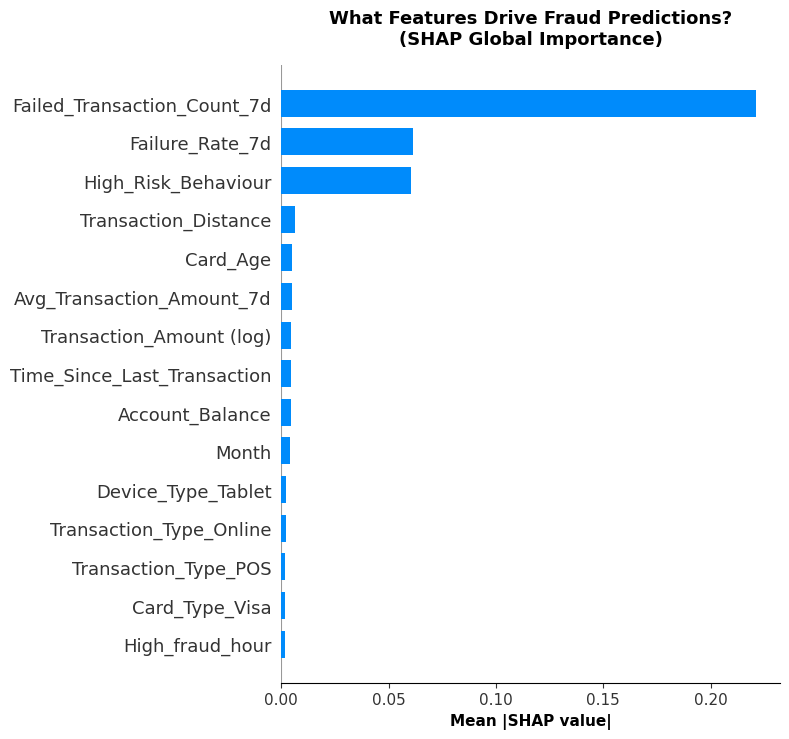

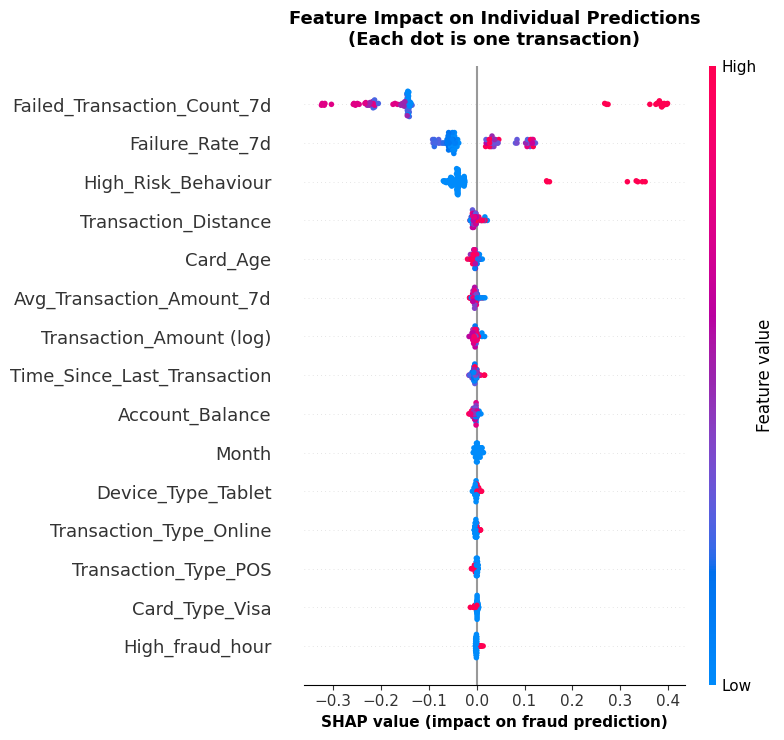


📋 Case Studies: Individual Transaction Explanations

🚨 HIGH-RISK TRANSACTION
🎯 Predicted Fraud Probability: 98.0%
📌 Feature Values & SHAP Contributions (Top 8):

  1. Failed_Transaction_Count_7d      Value:        4 | SHAP:  0.2676 (↑ INCREASES fraud risk)
  2. High_Risk_Behaviour              Value:        1 | SHAP:  0.1462 (↑ INCREASES fraud risk)
  3. Failure_Rate_7d                  Value: 0.3076923076923077 | SHAP:  0.0843 (↑ INCREASES fraud risk)
  4. Avg_Transaction_Amount_7d        Value:   407.42 | SHAP: -0.0037 (↓ DECREASES fraud risk)
  5. Time_Since_Last_Transaction      Value: 11187360.0 | SHAP: -0.0034 (↓ DECREASES fraud risk)
  6. Authentication_Method_Password   Value:      N/A | SHAP: -0.0028 (↓ DECREASES fraud risk)
  7. Card_Age                         Value:      162 | SHAP: -0.0023 (↓ DECREASES fraud risk)
  8. Transaction_Type_POS             Value:      N/A | SHAP: -0.0021 (↓ DECREASES fraud risk)

✅ LOW-RISK TRANSACTION
🎯 Predicted Fraud Probability: 4.6%
📌 Fea

In [95]:


print("=" * 80)
print("SHAP EXPLAINABILITY: Why Does the Model Make Predictions?")
print("=" * 80)

# Step 1: Prepare data
print("\n✓ Extracting Random Forest model for SHAP analysis...")
sample_size = 100
X_test_sample = X_test.iloc[:sample_size]
X_test_transformed = best_rf.named_steps['preprocess'].transform(X_test_sample)
rf_model = best_rf.named_steps['model']

# Background data for explainer
background_size = 50
X_train_transformed = best_rf.named_steps['preprocess'].transform(X_train.iloc[:background_size])

print(f"✓ Background (training) data: {X_train_transformed.shape}")
print(f"✓ Analysis (test) data: {X_test_transformed.shape}")

# Step 2: Create SHAP explainer
print(f"\n⏳ Generating SHAP values (processing {sample_size} test cases)...")
try:
    explainer = shap.TreeExplainer(rf_model)
    shap_values_raw = explainer.shap_values(X_test_transformed)
    
    # Handle 3D array from binary classification (samples, features, classes)
    if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
        shap_values_fraud = shap_values_raw[:, :, 1]  # Extract fraud class (class 1)
    elif isinstance(shap_values_raw, list):
        shap_values_fraud = shap_values_raw[1]  # For list-based output
    else:
        shap_values_fraud = shap_values_raw
        
    print(f"✓ SHAP values computed: {shap_values_fraud.shape}")
    
except Exception as e:
    print(f"⚠ Using KernelExplainer as fallback: {str(e)[:50]}...")
    explainer = shap.KernelExplainer(
        lambda x: rf_model.predict_proba(x)[:, 1],
        X_train_transformed
    )
    shap_values_fraud = explainer.shap_values(X_test_transformed)
    print(f"✓ SHAP values computed (KernelExplainer): {shap_values_fraud.shape}")

# Step 3: Summary Plot - Bar chart of feature importance
print("\n📊 Generating visualizations...")
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(
    shap_values_fraud,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=15
)
plt.title("What Features Drive Fraud Predictions?\n(SHAP Global Importance)", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Mean |SHAP value|', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 4: Summary Plot - Beeswarm
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_fraud,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
    max_display=15
)
plt.title("Feature Impact on Individual Predictions\n(Each dot is one transaction)", 
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('SHAP value (impact on fraud prediction)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Step 5: Case Study - Explain specific transactions
print("\n📋 Case Studies: Individual Transaction Explanations\n")
predictions = rf_model.predict_proba(X_test_transformed)[:, 1]

# Find a fraud case (high prediction) and normal case
fraud_idx = np.argsort(predictions)[-2]  # 2nd highest for real case
normal_idx = np.argsort(predictions)[0]  # Lowest prediction

# Create explanation dataframes
def explain_transaction(idx, pred_prob, label):
    """Create a simple explanation for a transaction."""
    shap_vals = shap_values_fraud[idx]
    feature_impacts = pd.DataFrame({
        'Feature': feature_names,
        'SHAP_Value': shap_vals,
        'Abs_Impact': np.abs(shap_vals)
    }).sort_values('Abs_Impact', ascending=False)
    
    print(f"{'='*70}")
    print(f"{label}")
    print(f"{'='*70}")
    print(f"🎯 Predicted Fraud Probability: {pred_prob:.1%}")
    print(f"📌 Feature Values & SHAP Contributions (Top 8):\n")
    
    for i, (_, row) in enumerate(feature_impacts.head(8).iterrows(), 1):
        impact_dir = "↑ INCREASES" if row['SHAP_Value'] > 0 else "↓ DECREASES"
        feat_val = X_test_sample[row['Feature']].iloc[idx] if row['Feature'] in X_test_sample.columns else "N/A"
        print(f"  {i}. {row['Feature']:<32} Value: {feat_val:>8} | SHAP: {row['SHAP_Value']:>7.4f} ({impact_dir} fraud risk)")
    print()

# Print explanations
explain_transaction(fraud_idx, predictions[fraud_idx], "🚨 HIGH-RISK TRANSACTION")
explain_transaction(normal_idx, predictions[normal_idx], "✅ LOW-RISK TRANSACTION")

# Step 6: Executive Summary
print("\n" + "=" * 80)
print("EXPLAINABILITY INSIGHTS FOR STAKEHOLDERS")
print("=" * 80)

# Calculate mean absolute SHAP values for overall feature importance
mean_shap = np.abs(shap_values_fraud).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Impact': mean_shap
}).sort_values('SHAP_Impact', ascending=False)

print("\n📌 Top 5 Most Influential Features (SHAP):")
for i, (idx, row) in enumerate(shap_importance_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['Feature']:<35} Impact: {row['SHAP_Impact']:.4f}")

print("\n✅ Model Interpretability: SHAP analysis reveals why each prediction is made.")
print("✅ Risk Scoring: Red (positive SHAP) = increases fraud risk, Blue (negative SHAP) = decreases risk.")
print("✅ Actionable Insights: Use feature impacts to refine fraud detection rules and investigate high-risk transactions.")
